# Hybrid Stock Forecasting — Grounding an LLM with Retrieval and Combining It with an LSTM
## NCI MSc Artificial Intelligence — Mukesh Mukkara (x24226432)

**Thesis:** Retrieval grounding, not fusion, is what improves an LLM trading assistant. Fusion adds
calibration and the ability to report internal disagreement. Neither beats the market on direction.

### The flow of this notebook

**Data → EDA → compare ML against DL → take the best → add AI → conclusion.**

Each stage exists because the previous one ran out of road. The data says the task is 5-day
direction against a ~55% always-UP baseline. Classical ML cannot clear that baseline, and neither
can deep learning — but the sequence models do hold up in shocks where the classical models fall
apart, which is why the ML arm is a recurrent network. Having established that no amount of
architecture search on price history helps, the remaining question is whether a different *kind* of
information does: language, then retrieved evidence, then the two fused.

| Stage | Section | Description |
|---|---|---|
| **Data** | 1. Data, features & EDA | 5 stocks, 2019–2024, 22 backward-looking features, VIX regimes |
| **Compare** | 2. Model selection | Logistic Regression, Random Forest, XGBoost vs GRU, LSTM |
| **AI** | 3. Evidence & retrieval | 252 dated items, TF-IDF, look-ahead guard tested |
| | 4. Arm 1 — ML | The selected LSTM, walk-forward with embargo |
| | 5. Arms 2 & 3 — LLM | Identical prompts, with and without evidence |
| | 6. Arm 4 — Hybrid | Calibrated logit pooling |
| **Evaluate** | 7. Backtest & evaluation | Accuracy, Brier, McNemar on 300 holdout rows |
| | 8. Hallucination audit | Three mechanical checks, 1,000 responses |
| | 9. Stability | Same prompt five times |
| | 10. Response quality | 100-point assistant rubric |
| **Conclude** | 11. Results summary | Every claim mapped to its evidence |

The four arms each remove exactly one capability from the one above, so any difference between two
rows is attributable to that capability alone: **ML only** (prices) → **LLM only** (+ language) →
**LLM + RAG** (+ retrieved evidence) → **Hybrid** (+ fusion).

### How this notebook relates to the code

`src/` holds only the eight modules the **live demo** needs — the shared engine that `app.py`
imports, so the numbers in this thesis and the numbers in the demo come from the same code. Every
piece of **research** code — the EDA, the model comparison, the backtest, the rubric, the figures —
is written out in this notebook rather than hidden behind an import.

Stages that cost real money or real time (training the networks, calling the LLM 1,000 times) sit
behind a `RUN_*` flag, default `False`. The code is shown and is runnable; with the flag off the
notebook reads the run that produced the reported results. Nothing is faked either way.

> **The live comparison runs in `app.py`.** This notebook establishes the numbers; the web demo puts
> all four arms side by side on a single question so the difference can be seen rather than read.
> `python app.py` → http://localhost:5000

## Setup

In [1]:
import json, sys, re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image

sys.path.insert(0, str(Path.cwd()))

# The eight modules the live demo also imports. Nothing research-only lives here.
from src import config as C, data_loader as D, evidence as E
from src import evaluation as V, hybrid as H, llm as L, ml_model as M

C.set_seeds()
pd.set_option('display.width', 130)
pd.set_option('display.max_columns', 30)

# Expensive stages are opt-in. Off = read the run that produced the reported
# results; on = regenerate it. See the note at the top of the notebook.
RUN_TRAINING   = False   # retrain the LSTM walk-forward           (~10-20 min CPU)
RUN_COMPARISON = False   # retrain all five candidate models       (~30-45 min CPU)
RUN_BACKTEST   = False   # call the LLM ~1,000 times               (needs GEMINI_API_KEY)

OUT = C.OUTPUT_DIR
results = json.loads((OUT / 'results.json').read_text(encoding='utf-8'))
th, wts, acc = results['thresholds'], results['weights'], results['accuracy']

print(f"Stocks     : {C.TICKERS}")
print(f"Period     : {C.START_DATE} to {C.END_DATE}, {C.PREDICT_DAYS}-day horizon")
print(f"Validation : {C.N_FOLDS}-fold walk-forward, {C.EMBARGO_DAYS}-day embargo")
print(f"Regime     : SHOCK when VIX > {C.VIX_SHOCK_LEVEL}")
print(f"LLM        : {C.GEMINI_MODEL} @ temp {C.LLM_TEMPERATURE}, anonymised={C.ANONYMISE_TICKERS}")
print(f"Retrieval  : TF-IDF top-{C.RAG_TOP_K}, {C.RAG_WINDOW_DAYS}-day window")
print(f"Holdout    : {results['n_holdout']} rows / {results['n_dates']} dates {results['by_regime']}")

Stocks     : ['NVDA', 'AAPL', 'TSLA', 'JPM', 'MSFT']
Period     : 2019-01-01 to 2024-12-31, 5-day horizon
Validation : 3-fold walk-forward, 5-day embargo
Regime     : SHOCK when VIX > 25.0
LLM        : gemini-2.5-flash @ temp 0.0, anonymised=True
Retrieval  : TF-IDF top-4, 90-day window
Holdout    : 300 rows / 60 dates {'CALM': 190, 'SHOCK': 110}


### One visual system for every figure

Defined once, here, so a reader moving between sections is never asked to relearn what a colour
means. Colour is never the only encoding: every series carries a direct label or a legend as well as
a hue, so the charts survive greyscale printing and colour-vision differences. The five categorical
steps were checked with a colour-vision simulator against this surface — the worst adjacent pair
separates by ΔE 23.1 under protanopia and 24.0 under normal vision, both above the thresholds for a
five-series chart.

In [2]:
matplotlib.use('Agg')

# Fixed order, never cycled. The first three are the pair/triple the results
# charts ask for by name; the last two extend the set to one hue per stock.
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#8b5cf6', '#b5952a']
BLUE, ORANGE, AQUA = CATEGORICAL[:3]

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE    = '#e1e0d9', '#fcfcfb'
CRITICAL         = '#d03b3b'          # reserved for state, never for a series

# One hue, light to dark - the correct ramp for a magnitude such as correlation.
SEQUENTIAL = matplotlib.colors.LinearSegmentedColormap.from_list(
    'thesis_blue', ['#f2f6fc', '#a9c6ea', '#2a78d6', '#17416f'])

# Stock -> hue, assigned once in a fixed order so a stock keeps its colour in
# every figure. Filtering a chart down to fewer stocks must not repaint them.
TICKER_COLOUR = {t: CATEGORICAL[i % len(CATEGORICAL)] for i, t in enumerate(C.TICKERS)}


def style_axes(ax, title=None, xlabel=None, ylabel=None, grid_axis='y'):
    """The house treatment: recessive grid and spines, ink-coloured text."""
    ax.set_facecolor(SURFACE)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('#c3c2b7')
    ax.tick_params(colors=MUTED, labelsize=9)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.grid(axis='x' if grid_axis == 'y' else 'y', visible=False)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=INK, fontsize=12, fontweight='600', loc='left', pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK2, fontsize=10)


def save_fig(fig, name):
    """Write a figure into outputs/ and return the path."""
    path = OUT / name
    fig.patch.set_facecolor(SURFACE)
    fig.tight_layout()
    fig.savefig(path, dpi=140, facecolor=SURFACE)
    plt.close(fig)
    return path

print('Visual system loaded.')

Visual system loaded.


---
# 1. Data, features and exploratory analysis

All 22 features are backward-looking ratios, so no future information enters a row. A day is SHOCK
when the VIX closes above 25 — published same-day, so the label uses nothing from the future.

Three of the choices the rest of the project makes are only defensible if the data is described
first, and this section is what those choices point back to:

* **The label is 5-day direction, not price.** The return distributions show why — daily returns are
  near-symmetric and centred on roughly zero, so a level forecast is dominated by the level itself.
* **The baseline is ~55%, not 50%.** That comes straight from the class balance measured below, and
  it is the number every later accuracy is judged against.
* **Every result is split by regime.** The volatility panel shows the two states are visibly
  different periods, not an arbitrary cut of a single population.

In [3]:
bundle = D.load_everything()
print(f"{len(bundle['tickers'])} stocks, {len(bundle['feature_names'])} features, "
      f"{len(bundle['closes_df'])} trading days")

display(pd.DataFrame([{'Stock': t,
                       'Rows': len(bundle['features'][t]),
                       'Up in 5d %': round(bundle['targets'][t].mean() * 100, 2)}
                      for t in bundle['tickers']]))

regimes = pd.Series({d: D.regime_of(bundle['vix'], d)[0] for d in bundle['closes_df'].index})
print(f"Shock days: {(regimes == 'SHOCK').mean() * 100:.1f}% of the period. Because shock days are")
print('only ~a fifth of the sample, every result below is also split by regime.')

5 stocks, 22 features, 1509 trading days


,Stock,Rows,Up in 5d %
0,NVDA,1460,58.84
1,AAPL,1460,59.25
2,TSLA,1460,54.11
3,JPM,1460,56.51
4,MSFT,1460,58.97


Shock days: 20.7% of the period. Because shock days are


only ~a fifth of the sample, every result below is also split by regime.


### The numbers the report quotes about the raw data

In [4]:
TRADING_DAYS = 252


def summary_table(bundle):
    """One row per stock: the numbers the report quotes about the raw data."""
    rows = []
    for tick in bundle['tickers']:
        close  = bundle['prices'][tick]['Close'].astype(float)
        volume = bundle['prices'][tick]['Volume'].astype(float)
        ret    = close.pct_change().dropna()
        # Peak-to-trough on the running maximum - the worst loss a holder would
        # have sat through over the period.
        drawdown = (close / close.cummax() - 1.0).min()
        rows.append({
            'ticker':             tick,
            'n_days':             len(close),
            'start':              close.index[0].strftime('%Y-%m-%d'),
            'end':                close.index[-1].strftime('%Y-%m-%d'),
            'total_return_pct':   round(float(close.iloc[-1] / close.iloc[0] - 1) * 100, 1),
            'mean_daily_ret_pct': round(float(ret.mean()) * 100, 4),
            'ann_volatility_pct': round(float(ret.std() * np.sqrt(TRADING_DAYS)) * 100, 1),
            'max_drawdown_pct':   round(float(drawdown) * 100, 1),
            'up_day_pct':         round(float((ret > 0).mean()) * 100, 2),
            # The label this project actually predicts, and therefore the
            # always-UP baseline the models have to beat.
            'up_in_5d_pct':       round(float(bundle['targets'][tick].mean()) * 100, 2),
            'avg_volume_m':       round(float(volume.mean()) / 1e6, 1),
        })
    return pd.DataFrame(rows)


def regime_balance(bundle):
    """Class balance split by regime - where the always-UP baseline comes from."""
    rows = []
    for tick in bundle['tickers']:
        y = bundle['targets'][tick]
        regs = pd.Series({d: D.regime_of(bundle['vix'], d)[0] for d in y.index}, index=y.index)
        for reg in ('CALM', 'SHOCK'):
            sub = y[regs == reg]
            if len(sub):
                rows.append({'ticker': tick, 'regime': reg, 'n': len(sub),
                             'up_pct': round(float(sub.mean()) * 100, 2)})
    return pd.DataFrame(rows)


summary = summary_table(bundle)
balance = regime_balance(bundle)
summary.to_csv(OUT / 'eda_summary.csv', index=False)
display(summary)

print(f"Always-UP baseline over the whole period: {summary['up_in_5d_pct'].mean():.2f}%")
print('Not 50%. Every accuracy in this notebook is judged against this rate, or')
print('against the equivalent rate for the regime in question.')

,ticker,n_days,start,end,total_return_pct,mean_daily_ret_pct,ann_volatility_pct,max_drawdown_pct,up_day_pct,up_in_5d_pct,avg_volume_m
0,NVDA,1509,2019-01-02,2024-12-30,3970.1,0.2991,51.9,-66.3,54.64,58.84,448.6
1,AAPL,1509,2019-01-02,2024-12-30,568.8,0.1450,30.8,-31.4,54.18,59.25,94.2
2,TSLA,1509,2019-01-02,2024-12-30,1918.9,0.2817,64.5,-73.6,53.05,54.11,127.5
3,JPM,1509,2019-01-02,2024-12-30,187.1,0.0885,30.7,-43.6,52.59,56.51,12.9
4,MSFT,1509,2019-01-02,2024-12-30,345.7,0.1159,29.0,-37.1,53.91,58.97,28.0


Always-UP baseline over the whole period: 57.54%
Not 50%. Every accuracy in this notebook is judged against this rate, or
against the equivalent rate for the regime in question.


### The EDA figures

In [5]:
def fig_price_trends(bundle):
    """Indexed to 100 on the first day, so five price levels share one axis."""
    fig, ax = plt.subplots(figsize=(11, 4.8))
    for tick in bundle['tickers']:
        close = bundle['prices'][tick]['Close'].astype(float)
        idx = close / close.iloc[0] * 100
        ax.plot(idx.index, idx.values, color=TICKER_COLOUR[tick], linewidth=2, label=tick, zorder=3)
        # Direct label at the line end, so identity is never colour-alone.
        ax.annotate(tick, (idx.index[-1], idx.iloc[-1]), textcoords='offset points',
                    xytext=(6, 0), va='center', color=INK2, fontsize=9, fontweight='600')
    ax.axhline(100, color=MUTED, linewidth=1.2, linestyle=':', zorder=2)
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, ncol=5, loc='upper left')
    style_axes(ax, title='Price history, indexed to 100 on the first trading day',
               xlabel='Date', ylabel='Index (first day = 100)')
    ax.margins(x=0.06)
    return save_fig(fig, 'eda1_price_trends.png')


def fig_returns_distribution(bundle):
    """Small multiples rather than five overlaid histograms, which would be unreadable."""
    ticks = bundle['tickers']
    fig, axes = plt.subplots(1, len(ticks), figsize=(15, 3.6), sharey=True)
    for ax, tick in zip(axes, ticks):
        ret = bundle['prices'][tick]['Close'].astype(float).pct_change().dropna() * 100
        ax.hist(ret, bins=60, color=TICKER_COLOUR[tick], zorder=3, edgecolor=SURFACE, linewidth=0.4)
        ax.axvline(0, color=MUTED, linewidth=1.2, linestyle=':', zorder=4)
        ax.text(0.97, 0.95, f"mean {ret.mean():+.2f}%\nsd {ret.std():.2f}%",
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color=INK2)
        style_axes(ax, title=tick, xlabel='Daily return (%)')
        ax.set_xlim(-12, 12)
    axes[0].set_ylabel('Trading days', color=INK2, fontsize=10)
    fig.suptitle('Daily return distributions - near-symmetric and centred on zero',
                 color=INK, fontsize=13, fontweight='650', x=0.01, ha='left')
    return save_fig(fig, 'eda2_returns_dist.png')


def _heatmap(ax, matrix, labels, title):
    """A single-hue sequential heatmap with every cell labelled."""
    im = ax.imshow(matrix, cmap=SEQUENTIAL, vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)), labels, fontsize=9, color=INK2)
    ax.set_yticks(range(len(labels)), labels, fontsize=9, color=INK2)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = matrix[i, j]
            # Ink flips on the dark end of the ramp so every cell label stays legible.
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5,
                    fontweight='600', color=SURFACE if v > 0.62 else INK)
    ax.set_title(title, color=INK, fontsize=11, fontweight='600', loc='left', pad=10)
    ax.tick_params(colors=MUTED, length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    return im


def fig_correlation(bundle):
    """Price levels correlate for trivial reasons; returns are the honest view."""
    ticks  = bundle['tickers']
    closes = bundle['closes_df'][ticks]
    rets   = closes.pct_change().dropna()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    _heatmap(axes[0], closes.corr().values, ticks, 'Price levels')
    im = _heatmap(axes[1], rets.corr().values, ticks, 'Daily returns')
    cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.03)
    cbar.set_label('Pearson correlation', color=INK2, fontsize=9.5)
    cbar.ax.tick_params(colors=MUTED, labelsize=8.5)
    cbar.outline.set_visible(False)
    fig.suptitle('Correlation between the five stocks', color=INK, fontsize=13,
                 fontweight='650', x=0.01, ha='left')
    # tight_layout fights the colorbar, so this figure lays itself out.
    path = OUT / 'eda3_correlation.png'
    fig.patch.set_facecolor(SURFACE)
    fig.savefig(path, dpi=140, facecolor=SURFACE, bbox_inches='tight')
    plt.close(fig)
    return path


def fig_volatility(bundle):
    """Rolling volatility with the VIX shock threshold marked.

    This is the figure that justifies splitting every later result by regime:
    the shaded periods are visibly a different market, not a slice of one.
    """
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, height_ratios=[2, 1])
    for tick in bundle['tickers']:
        close = bundle['prices'][tick]['Close'].astype(float)
        rv = close.pct_change().rolling(20).std() * np.sqrt(TRADING_DAYS) * 100
        ax.plot(rv.index, rv.values, color=TICKER_COLOUR[tick], linewidth=1.6, label=tick, zorder=3)
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, ncol=5, loc='upper right')
    style_axes(ax, title='20-day rolling annualised volatility, by stock',
               ylabel='Annualised volatility (%)')

    vix = bundle['vix']
    ax2.plot(vix.index, vix.values, color=MUTED, linewidth=1.4, zorder=3)
    ax2.axhline(C.VIX_SHOCK_LEVEL, color=CRITICAL, linewidth=2, linestyle='--', zorder=4)
    ax2.fill_between(vix.index, C.VIX_SHOCK_LEVEL, vix.values,
                     where=(vix.values > C.VIX_SHOCK_LEVEL), color=CRITICAL, alpha=0.18, zorder=2)
    ax2.text(vix.index[5], C.VIX_SHOCK_LEVEL + 3, f'SHOCK: VIX > {C.VIX_SHOCK_LEVEL:.0f}',
             color=CRITICAL, fontsize=9, fontweight='600')
    style_axes(ax2, title='The VIX, and the days this project calls a shock',
               xlabel='Date', ylabel='VIX')
    return save_fig(fig, 'eda4_volatility.png')


def fig_returns_box(bundle):
    """Spread and tails side by side - the comparison a histogram grid cannot make."""
    ticks = bundle['tickers']
    data = [bundle['prices'][t]['Close'].astype(float).pct_change().dropna().values * 100
            for t in ticks]
    fig, ax = plt.subplots(figsize=(9, 4.6))
    bp = ax.boxplot(data, tick_labels=ticks, patch_artist=True, showmeans=True, widths=0.55,
                    medianprops=dict(color=INK, linewidth=1.6),
                    meanprops=dict(marker='D', markerfacecolor=SURFACE,
                                   markeredgecolor=INK, markersize=5),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.35,
                                    markerfacecolor=MUTED, markeredgecolor='none'),
                    whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    for patch, tick in zip(bp['boxes'], ticks):
        patch.set_facecolor(TICKER_COLOUR[tick])
        patch.set_alpha(0.55)
        patch.set_edgecolor(SURFACE)
        patch.set_linewidth(2)
    ax.axhline(0, color=MUTED, linewidth=1.2, linestyle=':', zorder=2)
    style_axes(ax, title='Daily return spread by stock (diamond = mean, line = median)',
               ylabel='Daily return (%)')
    return save_fig(fig, 'eda5_returns_box.png')


def fig_volume(bundle):
    """Average traded volume - context for the volume-ratio feature the models read."""
    ticks = bundle['tickers']
    vals = [float(bundle['prices'][t]['Volume'].astype(float).mean()) / 1e6 for t in ticks]
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    bars = ax.bar(ticks, vals, width=0.6, zorder=3, color=[TICKER_COLOUR[t] for t in ticks])
    for b in bars:
        b.set_linewidth(2)
        b.set_edgecolor(SURFACE)
    for x, v in zip(ticks, vals):
        ax.text(x, v + max(vals) * 0.02, f'{v:.1f}M', ha='center', fontsize=9.5,
                color=INK, fontweight='600')
    ax.set_ylim(0, max(vals) * 1.16)
    style_axes(ax, title='Average daily trading volume', ylabel='Shares (millions)')
    return save_fig(fig, 'eda6_volume.png')


def fig_candlestick(bundle):
    """A 60-day window around the most volatile day in the period.

    Drawn on the peak-VIX window rather than the last 60 days, because the point
    of this figure is to show what the price data looks like in the regime the
    research question is about.
    """
    vix  = bundle['vix']
    peak = vix.idxmax()
    tick = max(bundle['tickers'],
               key=lambda t: bundle['prices'][t]['Close'].astype(float).pct_change().std())
    df = bundle['prices'][tick]
    window = pd.concat([df.loc[:peak].tail(30), df.loc[peak:].head(30)[1:]])

    fig, ax = plt.subplots(figsize=(11, 4.8))
    for date, row in window.iterrows():
        colour = TICKER_COLOUR[tick] if float(row['Close']) >= float(row['Open']) else CRITICAL
        ax.plot([date, date], [float(row['Low']), float(row['High'])],
                color=colour, linewidth=1, zorder=3)
        ax.plot([date, date], [float(row['Open']), float(row['Close'])],
                color=colour, linewidth=4, solid_capstyle='butt', zorder=4)
    ax.axvline(peak, color=MUTED, linewidth=1.4, linestyle='--', zorder=2)
    ax.text(peak, ax.get_ylim()[1], f'  peak VIX {float(vix.max()):.0f}',
            color=INK2, fontsize=9, fontweight='600', va='top')
    style_axes(ax, title=f"{tick} around the most volatile day in the period "
                         f"({peak.strftime('%d %b %Y')})", xlabel='Date', ylabel='Price (USD)')
    fig.autofmt_xdate(rotation=0, ha='center')
    return save_fig(fig, 'eda7_candlestick.png')


def fig_regime_balance(balance):
    """The always-UP baseline per regime - what every later result is judged against."""
    ticks = list(dict.fromkeys(balance['ticker']))
    x, w = np.arange(len(ticks)), 0.36
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    for i, (reg, colour, label) in enumerate([('CALM', TICKER_COLOUR[C.TICKERS[0]], 'Calm'),
                                              ('SHOCK', CRITICAL, 'Shock')]):
        sub = balance[balance['regime'] == reg].set_index('ticker')
        vals = [float(sub.loc[t, 'up_pct']) if t in sub.index else 0.0 for t in ticks]
        bars = ax.bar(x + (i - 0.5) * w, vals, width=w, color=colour, label=label,
                      zorder=3, alpha=0.9)
        for b in bars:
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
        for xi, v in zip(x + (i - 0.5) * w, vals):
            ax.text(xi, v + 1, f'{v:.0f}', ha='center', fontsize=9, color=INK, fontweight='600')
    ax.axhline(50, color=MUTED, linewidth=1.4, linestyle=':', zorder=2)
    ax.text(-0.48, 51.2, 'coin flip', color=MUTED, fontsize=9, ha='left')
    ax.set_xticks(x, ticks, fontsize=10, color=INK2)
    ax.legend(frameon=False, fontsize=10, labelcolor=INK2)
    ax.set_ylim(0, 80)
    style_axes(ax, title=f'How often the price is higher {C.PREDICT_DAYS} trading days later',
               ylabel='% of days that went UP')
    return save_fig(fig, 'eda8_regime_balance.png')


for f in (fig_price_trends, fig_returns_distribution, fig_correlation, fig_volatility,
          fig_returns_box, fig_volume, fig_candlestick):
    print(' ', f(bundle).name)
print(' ', fig_regime_balance(balance).name)

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


  eda1_price_trends.png


findfont: Failed to find font weight 650, now using 700.


findfont: Failed to find font weight 600, now using 700.


...

findfont: Failed to find font weight 600, now using 700.


  eda5_returns_box.png


  eda6_volume.png


  eda7_candlestick.png


  eda8_regime_balance.png


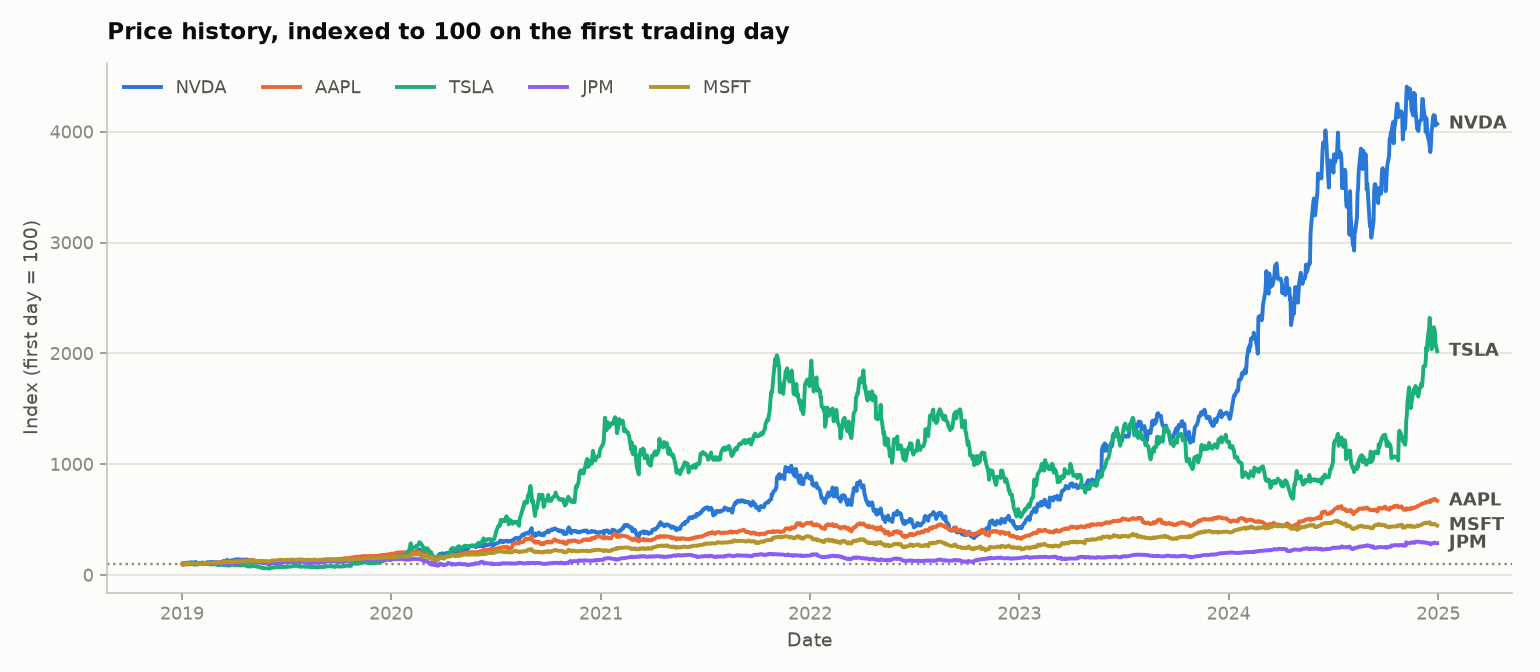

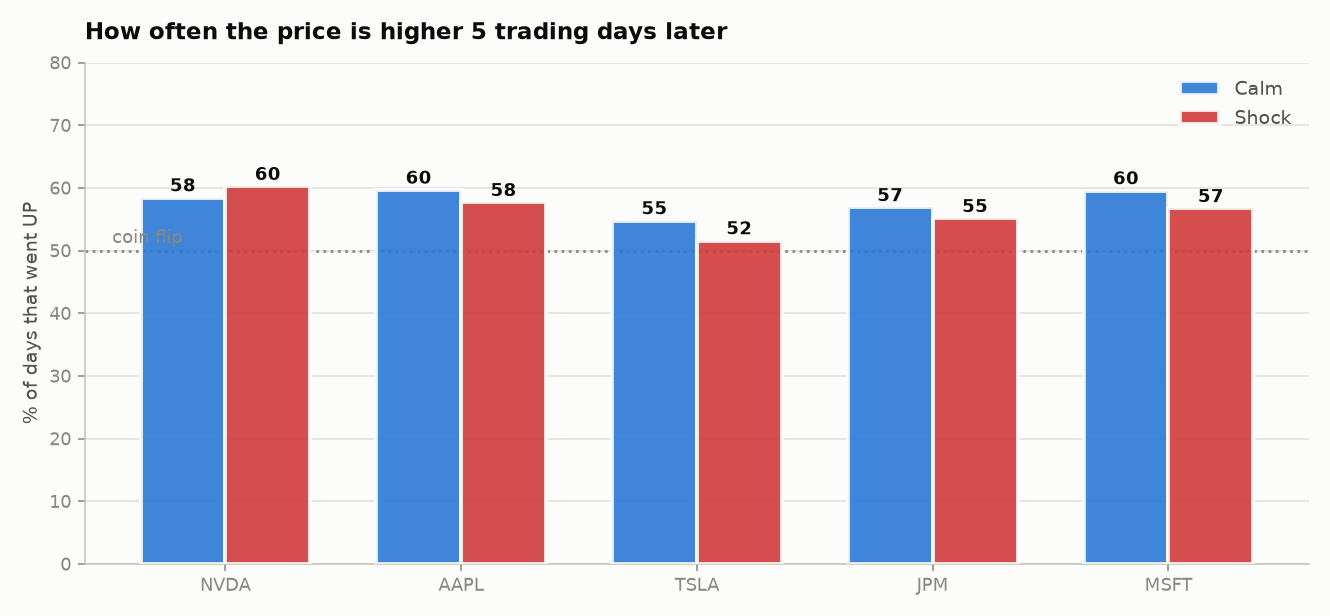

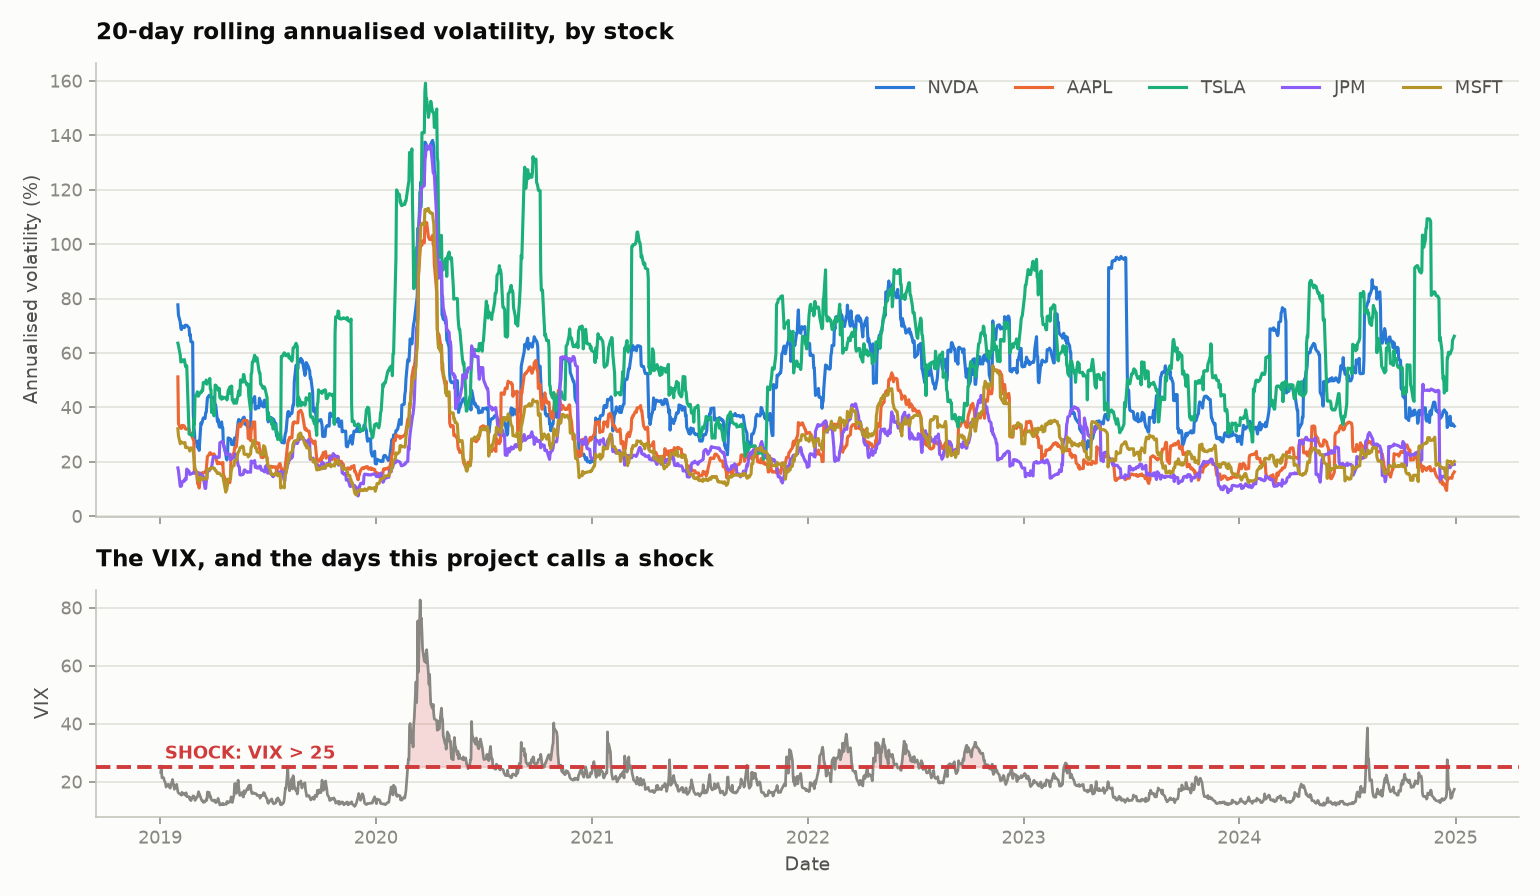

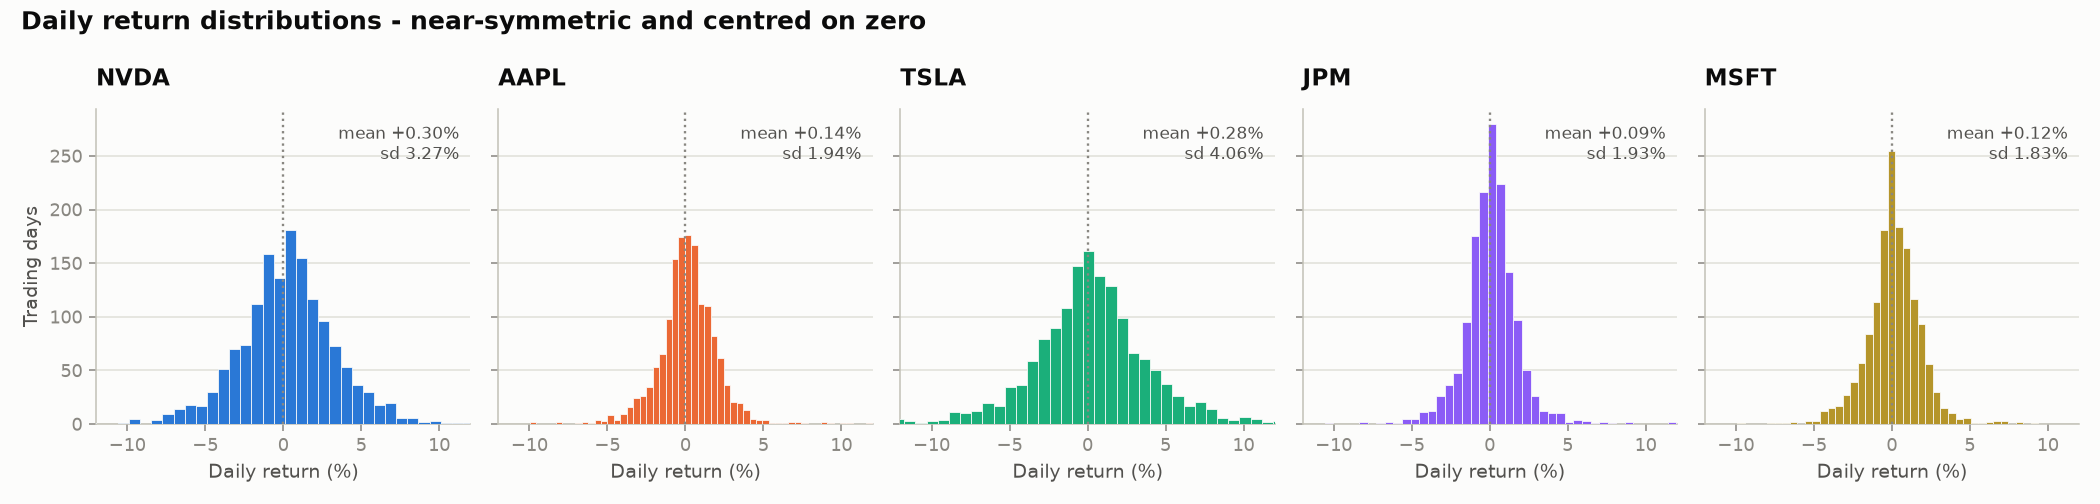

In [6]:
display(Image(filename=str(OUT / 'eda1_price_trends.png')))
display(Image(filename=str(OUT / 'eda8_regime_balance.png')))

# Why every result below is split by regime: the two states are visibly
# different markets, not an arbitrary cut of one population.
display(Image(filename=str(OUT / 'eda4_volatility.png')))

# Why the label is direction and not price: returns are near-symmetric and
# centred on roughly zero, so a level forecast is dominated by the level itself.
display(Image(filename=str(OUT / 'eda2_returns_dist.png')))

---
# 2. Model selection — classical ML against deep learning

The ML arm is an LSTM. That is only defensible if the alternatives were tried on the same task, so
five candidates are run over identical walk-forward folds, the same embargo, the same features, each
with its own threshold tuned on validation only.

**What makes the comparison fair.** Every model here is judged on identical terms: the same
walk-forward folds and the same 5-day embargo; the same engineered features; pooled across all five
stocks, so each model sees the same ~4,400 out-of-sample rows; and its own decision threshold, tuned
on that fold's validation slice and never on test.

**The one asymmetry, stated plainly.** The sequence models read a 60-day window; the classical models
read the single feature row for the day. That is the comparison, not a handicap: the features are
already backward-looking (returns over 1/5/10/20 days, moving-average ratios, RSI, ATR), so a tree or
a linear model has the recent past available in summarised form. What the sequence models add is the
*shape* of those 60 days. Flattening the window instead would hand the classical models 1,320 columns
on roughly 4,000 training rows, which measures overfitting rather than architecture.

The LSTM row is not retrained here. It is read from `outputs/ml_predictions.csv`, so the model
compared against the alternatives is literally the model the thesis reports.

In [7]:
# Display order: classical first, deep second, so the table reads as the argument
# it is - "here is the simple thing, here is what sequence adds".
CLASSICAL = ['Logistic Regression', 'Random Forest', 'XGBoost']
DEEP      = ['GRU', 'LSTM']
MODEL_ORDER = CLASSICAL + DEEP
FAMILY = {**{m: 'Classical ML' for m in CLASSICAL}, **{m: 'Deep learning' for m in DEEP}}

COMPARISON_CSV  = OUT / 'model_comparison.csv'
PREDICTIONS_CSV = OUT / 'model_comparison_predictions.csv'
SELECTED_JSON   = OUT / 'model_selection.json'


def build_gru(n_features, seq_len=None):
    """The GRU counterpart of ml_model.build_lstm, matched layer for layer.

    Same depth, same widths, same dropout, same optimiser - only the recurrent
    cell differs, so a difference in the result is attributable to the cell.
    """
    import keras
    from keras.models import Sequential
    from keras.layers import GRU, Dense, Dropout, Input
    model = Sequential([
        Input(shape=(seq_len or C.SEQ_LEN, n_features)),
        GRU(64, return_sequences=True), Dropout(0.3),
        GRU(32), Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


def build_classical(name, seed):
    """One of the three non-sequence baselines."""
    if name == 'Logistic Regression':
        from sklearn.linear_model import LogisticRegression
        return LogisticRegression(max_iter=2000, C=1.0, random_state=seed)
    if name == 'Random Forest':
        from sklearn.ensemble import RandomForestClassifier
        return RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                      n_jobs=-1, random_state=seed)
    if name == 'XGBoost':
        from xgboost import XGBClassifier
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                             eval_metric='logloss', n_jobs=-1, random_state=seed)
    raise ValueError(f'unknown model {name}')


def tune_threshold_cv(p_val, y_val):
    """The cut-off that maximises accuracy on the validation slice.

    Identical to what ml_model.train_and_predict does for the LSTM, so no model
    in this table is judged at a cut-off another one was allowed to optimise.
    """
    best_t, best_acc = 0.5, -1.0
    for t in np.arange(0.30, 0.71, 0.01):
        a = float(((p_val >= t).astype(int) == y_val).mean())
        if a > best_acc:
            best_acc, best_t = a, float(t)
    return round(best_t, 3)


def run_walk_forward(bundle, model_name, verbose=True):
    """Train `model_name` walk-forward and return its out-of-sample predictions."""
    from sklearn.preprocessing import StandardScaler
    C.set_seeds()
    tickers, features, targets = bundle['tickers'], bundle['features'], bundle['targets']
    n_feat  = len(bundle['feature_names'])
    n_rows  = min(len(features[t]) for t in tickers)
    is_deep = model_name in DEEP

    rows = []
    for fold, (tr_idx, te_idx) in enumerate(M.walk_forward_splits(n_rows), start=1):
        fit_rows, val_rows = M.inner_val_split(len(tr_idx))
        # The scaler sees only the fitting rows - never validation, never test.
        scaler = StandardScaler().fit(
            np.vstack([features[t].values[:n_rows][fit_rows] for t in tickers]))
        scaled = {t: np.clip(scaler.transform(features[t].values[:n_rows]), -5, 5) for t in tickers}
        ys = {t: targets[t].values[:n_rows] for t in tickers}

        if is_deep:
            import keras
            keras.utils.set_random_seed(C.RAND_SEED + fold)
            Xtr_l, ytr_l, Xva_l, yva_l = [], [], [], []
            for t in tickers:
                a, b, _ = M.make_sequences(scaled[t], ys[t], fit_rows)
                c, d, _ = M.make_sequences(scaled[t], ys[t], val_rows)
                Xtr_l.append(a); ytr_l.append(b); Xva_l.append(c); yva_l.append(d)
            Xtr, ytr = np.concatenate(Xtr_l), np.concatenate(ytr_l)
            Xva, yva = np.concatenate(Xva_l), np.concatenate(yva_l)
            builder = build_gru if model_name == 'GRU' else M.build_lstm
            model = M.fit_model(builder(n_feat), Xtr, ytr, Xva, yva)
            p_val = model.predict(Xva, verbose=0).ravel()
        else:
            # Same rows, minus the 60-day window: one feature vector per day.
            Xtr = np.vstack([scaled[t][fit_rows] for t in tickers])
            ytr = np.concatenate([ys[t][fit_rows] for t in tickers])
            Xva = np.vstack([scaled[t][val_rows] for t in tickers])
            yva = np.concatenate([ys[t][val_rows] for t in tickers])
            model = build_classical(model_name, C.RAND_SEED + fold)
            model.fit(Xtr, ytr)
            p_val = model.predict_proba(Xva)[:, 1]

        threshold = tune_threshold_cv(p_val, yva)
        if verbose:
            print(f'    fold {fold}: train={len(Xtr)} val={len(Xva)} threshold={threshold}')

        for t in tickers:
            if is_deep:
                Xte, yte, kept = M.make_sequences(scaled[t], ys[t], te_idx)
                if len(Xte) == 0:
                    continue
                p = model.predict(Xte, verbose=0).ravel()
            else:
                kept = np.asarray(list(te_idx))
                if len(kept) == 0:
                    continue
                yte = ys[t][kept]
                p = model.predict_proba(scaled[t][kept])[:, 1]
            for date, prob, truth in zip(features[t].index[:n_rows][kept], p, yte):
                regime, vix_level = D.regime_of(bundle['vix'], date)
                rows.append({'model': model_name, 'family': FAMILY[model_name],
                             'date': date.strftime('%Y-%m-%d'), 'ticker': t, 'fold': fold,
                             'p_up': round(float(prob), 6), 'threshold': threshold,
                             'y_true': int(truth), 'regime': regime,
                             'vix': round(float(vix_level), 2)})
    return pd.DataFrame(rows)


if RUN_COMPARISON:
    frames = []
    lstm = pd.read_csv(M.PRED_FILE).assign(model='LSTM', family=FAMILY['LSTM'])
    frames.append(lstm[['model', 'family', 'date', 'ticker', 'fold', 'p_up',
                        'threshold', 'y_true', 'regime', 'vix']])
    print('  LSTM: reusing outputs/ml_predictions.csv (the reported model)')
    for name in MODEL_ORDER:
        if name == 'LSTM':
            continue
        print(f'  {name}: training walk-forward...')
        frames.append(run_walk_forward(bundle, name))
    model_preds = pd.concat(frames, ignore_index=True)
    model_preds.to_csv(PREDICTIONS_CSV, index=False)
else:
    model_preds = pd.read_csv(PREDICTIONS_CSV)

print(f"\n{len(model_preds)} predictions from {model_preds['model'].nunique()} models")


21900 predictions from 5 models

### Scoring, and the rule that picks the ML arm

Ranking is on **shock** accuracy, not overall: the research question is about what happens when the
market breaks, and a model a point better in calm markets and worse in shocks is the wrong half of
the comparison to build on.

But a ranking is not a result. Two things are tested rather than assumed:

1. **Family.** Do the sequence models beat the classical ones in shocks? This is the comparison the
   stage exists to make, and it is the part with a gap big enough to mean something.
2. **The top pair.** Is the leader actually distinguishable from the incumbent the rest of the
   project is built on? An exact paired McNemar on the same rows answers that. If it is not, saying
   so and keeping the incumbent is the honest move — swapping architectures on an insignificant
   2-point gap is the same overfitting to a small sample this project refuses elsewhere.

The point of a model-selection stage is to report what the comparison supports, which is not always
the thing that came top.

In [8]:
def score(preds):
    """Accuracy, F1, AUC and Brier per model, overall and by regime."""
    from sklearn.metrics import f1_score, roc_auc_score
    rows = []
    for name in MODEL_ORDER:
        sub = preds[preds['model'] == name]
        if not len(sub):
            continue
        y = sub['y_true'].values
        pred = (sub['p_up'].values >= sub['threshold'].values).astype(int)
        entry = {'model': name, 'family': FAMILY[name], 'n': int(len(sub)),
                 'accuracy': round(float((pred == y).mean()) * 100, 2),
                 'f1':  round(float(f1_score(y, pred, zero_division=0)) * 100, 2),
                 'auc': round(float(roc_auc_score(y, sub['p_up'].values)) * 100, 2)
                        if len(np.unique(y)) > 1 else float('nan'),
                 'brier': round(float(np.mean((sub['p_up'].values - y) ** 2)), 4)}
        for reg in ('CALM', 'SHOCK'):
            m = sub['regime'].values == reg
            entry[f'acc_{reg.lower()}'] = (round(float((pred[m] == y[m]).mean()) * 100, 2)
                                           if m.sum() else float('nan'))
        rows.append(entry)
    table = pd.DataFrame(rows)

    # The bar every model has to clear, on its own rows.
    any_model = preds[preds['model'] == MODEL_ORDER[0]]
    y = (any_model if len(any_model) else preds)['y_true'].values
    base = {'model': 'Baseline: always UP', 'family': 'Baseline', 'n': int(len(y)),
            'accuracy': round(float(y.mean()) * 100, 2),
            'f1': round(float(2 * y.mean() / (1 + y.mean())) * 100, 2),
            'auc': 50.0, 'brier': round(float(np.mean((y.mean() - y) ** 2)), 4)}
    for reg in ('CALM', 'SHOCK'):
        m = (any_model if len(any_model) else preds)['regime'].values == reg
        base[f'acc_{reg.lower()}'] = round(float(y[m].mean()) * 100, 2) if m.sum() else float('nan')
    return pd.concat([table, pd.DataFrame([base])], ignore_index=True)


def select_best(table, preds, incumbent='LSTM'):
    """Pick the ML arm, and record honestly how strong the evidence for it is."""
    models   = table[table['family'] != 'Baseline'].copy()
    baseline = table[table['family'] == 'Baseline'].iloc[0]
    ranked   = models.sort_values(['acc_shock', 'accuracy'], ascending=False)
    leader   = str(ranked.iloc[0]['model'])

    fam = {f: round(float(models[models['family'] == f]['acc_shock'].mean()), 2)
           for f in ('Classical ML', 'Deep learning')}

    def calls(name):
        sub = preds[preds['model'] == name].sort_values(['date', 'ticker'])
        return sub, (sub['p_up'].values >= sub['threshold'].values).astype(int)

    test = None
    if leader != incumbent and incumbent in set(preds['model']):
        a_rows, a_pred = calls(leader)
        b_rows, b_pred = calls(incumbent)
        if len(a_rows) == len(b_rows):
            y = a_rows['y_true'].values
            shock = a_rows['regime'].values == 'SHOCK'
            test = {'overall': V.mcnemar(y, a_pred, b_pred),
                    'shock':   V.mcnemar(y[shock], a_pred[shock], b_pred[shock])}

    significant = bool(test and test['shock']['p'] < 0.05)
    selected = leader if (significant or leader == incumbent) else incumbent
    if selected == leader:
        reason = (f'{leader} leads on shock accuracy and the difference is significant '
                  f'on a paired test')
    else:
        p = test['shock']['p'] if test else float('nan')
        reason = (f'{leader} ranks first on shock accuracy, but against {incumbent} the paired '
                  f'McNemar test on the shock rows gives p = {p:.2f}. On this sample the two are '
                  f'not distinguishable, so the incumbent {incumbent} is retained - the reported '
                  f'pipeline is built and validated on it, and swapping architectures on an '
                  f'insignificant gap would be fitting the sample rather than choosing a model')

    row = models[models['model'] == selected].iloc[0]
    return {'selected': selected, 'leader_on_shock': leader, 'significant': significant,
            'reason': reason, 'family': str(row['family']),
            'criterion': 'highest shock-regime accuracy, confirmed by paired McNemar',
            'shock_accuracy': float(row['acc_shock']),
            'overall_accuracy': float(row['accuracy']),
            'baseline_overall': float(baseline['accuracy']),
            'baseline_shock': float(baseline['acc_shock']),
            'beats_baseline_overall': bool(row['accuracy'] > baseline['accuracy']),
            'family_shock_accuracy': fam, 'mcnemar_leader_vs_incumbent': test,
            'ranking': [{'model': str(r['model']), 'shock': float(r['acc_shock']),
                         'overall': float(r['accuracy']), 'auc': float(r['auc'])}
                        for _, r in ranked.iterrows()]}


comp = score(model_preds)
sel  = select_best(comp, model_preds)
comp.to_csv(COMPARISON_CSV, index=False)
SELECTED_JSON.write_text(json.dumps(sel, indent=1), encoding='utf-8')

display(comp)
fam = sel['family_shock_accuracy']
print(f"In shocks: deep learning {fam['Deep learning']}% vs classical ML {fam['Classical ML']}%"
      f"  -> a {fam['Deep learning'] - fam['Classical ML']:.1f}pt gap,")
print('the only difference in this table large enough to mean anything.')

,model,family,n,accuracy,f1,auc,brier,acc_calm,acc_shock
0,Logistic Regression,Classical ML,4380,53.13,66.74,51.07,0.2536,53.42,51.67
1,Random Forest,Classical ML,4380,52.17,60.21,50.79,0.2543,52.76,49.17
2,XGBoost,Classical ML,4380,52.90,64.56,50.91,0.2730,53.77,48.47
3,GRU,Deep learning,4380,54.75,66.62,50.20,0.2561,54.64,55.28
4,LSTM,Deep learning,4380,53.84,66.15,50.04,0.2561,53.96,53.19
5,Baseline: always UP,Baseline,4380,54.98,70.95,50.00,0.2475,55.38,52.92


In shocks: deep learning 54.23% vs classical ML 49.77%  -> a 4.5pt gap,
the only difference in this table large enough to mean anything.


### The comparison figure, with the selection rule on the chart

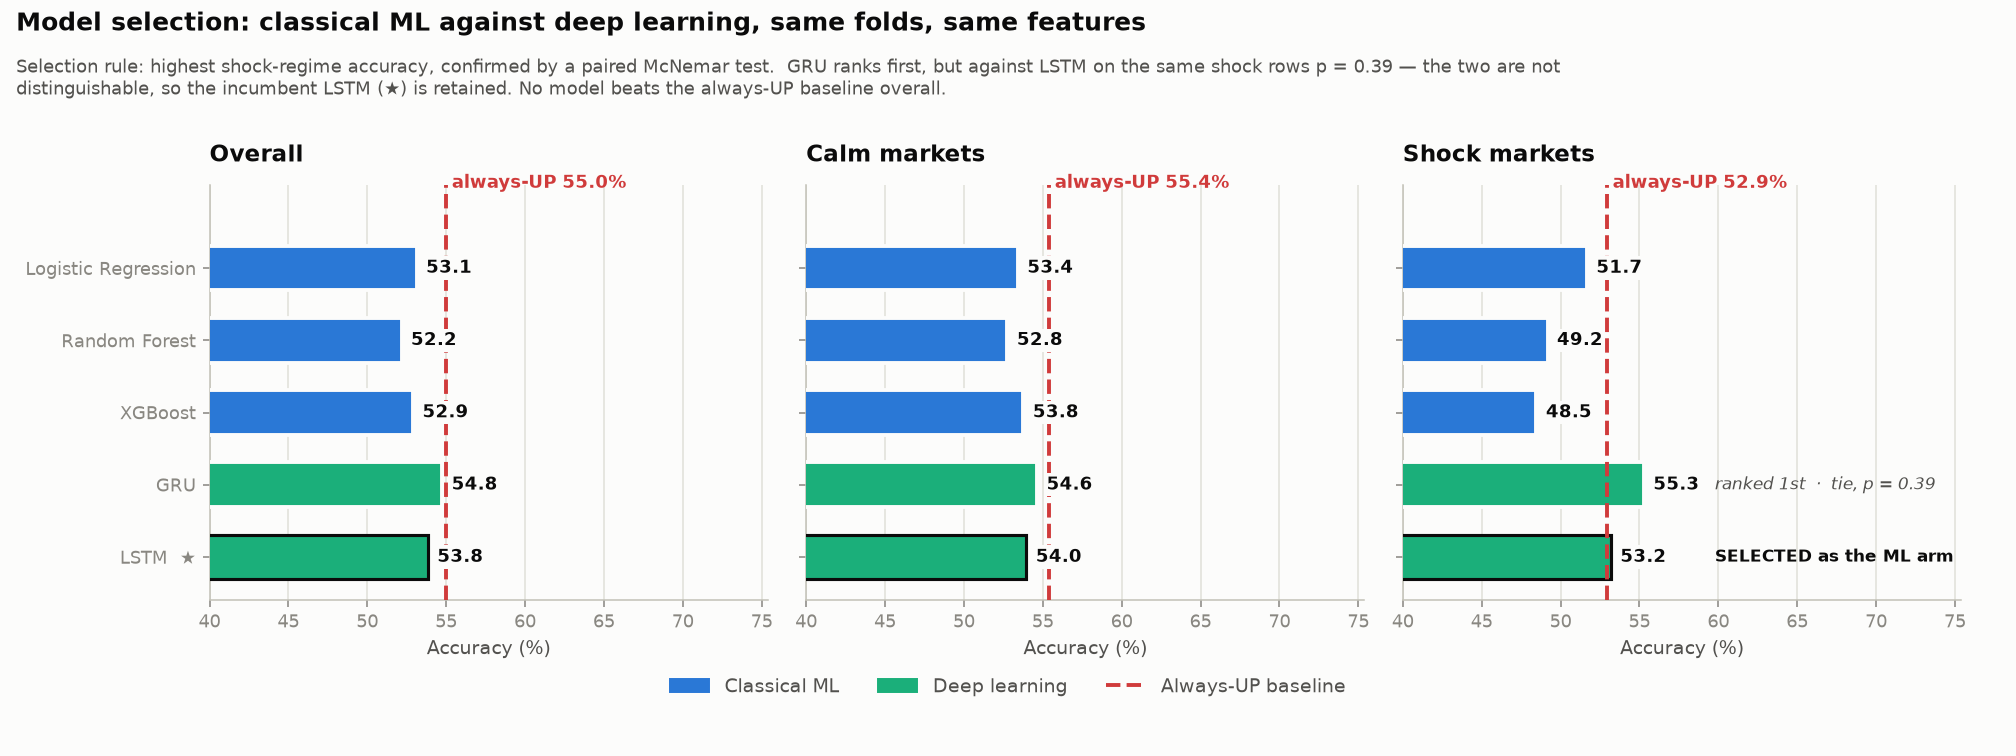

In [9]:
def fig_comparison(table, sel):
    """Overall / calm / shock accuracy per model, against the always-UP baseline.

    The selection rule is drawn onto the figure rather than left to the caption:
    a reader who sees GRU on top of the shock panel and LSTM named as the ML arm
    is owed the reason on the same page.
    """
    selected, leader = sel['selected'], sel['leader_on_shock']
    p_shock = (sel.get('mcnemar_leader_vs_incumbent') or {}).get('shock', {}).get('p')
    models  = [m for m in MODEL_ORDER if m in set(table['model'])]
    t = table.set_index('model')
    panels = [('accuracy', 'Overall'), ('acc_calm', 'Calm markets'), ('acc_shock', 'Shock markets')]

    # One shared x-range so a bar's length means the same thing in all three panels.
    all_vals = [float(t.loc[m, c]) for m in models for c, _ in panels]
    all_base = [float(table[table['family'] == 'Baseline'][c].iloc[0]) for c, _ in panels]
    XMAX = max(all_vals + all_base) + 20

    fig, axes = plt.subplots(1, 3, figsize=(14.4, 5.4), sharey=True)
    for ax, (col, title) in zip(axes, panels):
        vals = [float(t.loc[m, col]) for m in models]
        base = float(table[table['family'] == 'Baseline'][col].iloc[0])
        colours = [BLUE if FAMILY[m] == 'Classical ML' else AQUA for m in models]
        y = np.arange(len(models))

        bars = ax.barh(y, vals, height=0.62, color=colours, zorder=3)
        for m, b in zip(models, bars):
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
            # The selected model keeps an ink outline in every panel, so the eye
            # can find it without re-reading the labels.
            if m == selected:
                b.set_edgecolor(INK)
                b.set_linewidth(1.6)

        ax.axvline(base, color=CRITICAL, linewidth=2, linestyle='--', zorder=4)

        # A surface-coloured backing box so the baseline rule passes behind the
        # value label instead of striking through the digits.
        for i, v in enumerate(vals):
            ax.text(v + 0.6, i, f'{v:.1f}', va='center', fontsize=9.5, color=INK,
                    fontweight='600', zorder=6,
                    bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1.2))

        # The selection is decided on the shock panel, so it is tagged there.
        if col == 'acc_shock':
            tag_x = max(vals) + 4.5
            for i, m in enumerate(models):
                if m == leader and m != selected and p_shock is not None:
                    ax.text(tag_x, i, f'ranked 1st  ·  tie, p = {p_shock:.2f}',
                            va='center', fontsize=8.6, color=INK2, style='italic')
                elif m == selected:
                    ax.text(tag_x, i, 'SELECTED as the ML arm', va='center',
                            fontsize=8.6, color=INK, fontweight='700')

        ax.set_yticks(y, [f'{m}  ★' if m == selected else m for m in models],
                      fontsize=9.5, color=INK2)
        ax.invert_yaxis()
        ax.set_ylim(len(models) - 0.4, -1.15)
        ax.set_xlim(40, XMAX)
        style_axes(ax, title=title, xlabel='Accuracy (%)', grid_axis='x')
        ax.text(base, -1.05, f' always-UP {base:.1f}%', color=CRITICAL,
                fontsize=9, fontweight='600', va='bottom')

    handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
               plt.Rectangle((0, 0), 1, 1, color=AQUA),
               plt.Line2D([], [], linestyle='--', color=CRITICAL, linewidth=2)]
    fig.legend(handles, ['Classical ML', 'Deep learning', 'Always-UP baseline'], frameon=False,
               fontsize=10, labelcolor=INK2, ncol=3, loc='lower center',
               bbox_to_anchor=(0.5, 0.055))
    fig.suptitle('Model selection: classical ML against deep learning, same folds, same features',
                 color=INK, fontsize=13, fontweight='650', x=0.008, ha='left', y=0.985)
    fig.text(0.008, 0.925,
             f'Selection rule: highest shock-regime accuracy, confirmed by a paired McNemar test.  '
             f'{leader} ranks first, but against {selected} on the same shock rows '
             f'p = {p_shock:.2f} — the two are not\ndistinguishable, so the incumbent '
             f'{selected} (★) is retained. No model beats the always-UP baseline overall.',
             color=INK2, fontsize=9.3, ha='left', va='top')
    fig.tight_layout(rect=(0, 0.10, 1, 0.90))
    fig.patch.set_facecolor(SURFACE)
    path = OUT / 'model1_comparison.png'
    fig.savefig(path, dpi=140, facecolor=SURFACE)
    plt.close(fig)
    return path


fig_comparison(comp, sel)
display(Image(filename=str(OUT / 'model1_comparison.png')))

### Is the GRU/LSTM difference real? Tested three ways, not asserted

GRU ranks first on shock accuracy, so the honest question is whether that ranking would survive being
run again. Three checks, all on the predictions already saved:

1. **A paired McNemar test** — only the rows where the two models disagree carry information.
2. **Spread across folds** — a model whose accuracy swings between folds has not found something
   stable, whatever its mean says.
3. **Spread across stocks** — the same, for generalisation across instruments.

In [10]:
mc = sel.get('mcnemar_leader_vs_incumbent') or {}
print(f"Ranked first on shocks : {sel['leader_on_shock']}")
if mc:
    print(f"McNemar vs LSTM, all rows  : n01={mc['overall']['n01']}  n10={mc['overall']['n10']}  "
          f"p = {mc['overall']['p']:.2f}")
    print(f"McNemar vs LSTM, shock rows: n01={mc['shock']['n01']}  n10={mc['shock']['n10']}  "
          f"p = {mc['shock']['p']:.2f}   -> not distinguishable")
print(f"Selected as the ML arm : {sel['selected']}")

# --- consistency of each model, across folds and across stocks
d = model_preds.copy()
d['ok'] = (d['p_up'] >= d['threshold']).astype(int) == d['y_true']

by_fold  = d.groupby(['model', 'fold'])['ok'].mean().unstack() * 100
by_stock = d.groupby(['model', 'ticker'])['ok'].mean().unstack() * 100

stab = pd.DataFrame({
    'mean acc %':      by_fold.mean(axis=1).round(2),
    'sd across folds': by_fold.std(axis=1).round(2),
    'sd across stocks': by_stock.std(axis=1).round(2),
    'worst stock %':   by_stock.min(axis=1).round(2),
}).reindex(MODEL_ORDER)
display(stab)

print('Read this honestly: on THIS sample the consistency evidence does not separate the two')
print('recurrent nets either, and where it leans it leans towards GRU - GRU varies less across')
print(f"stocks (sd {stab.loc['GRU', 'sd across stocks']:.2f} vs "
      f"{stab.loc['LSTM', 'sd across stocks']:.2f}) and the two are level across folds.")
print('Fold-level SHOCK accuracy is deliberately NOT reported here: fold 3 contains only 20 shock')
print('rows, so its shock accuracy is noise and any variance statistic built on it would be too.')
print()
print('So the conclusion is a tie on every axis measured, and the tie-break is stated rather than')
print('hidden: the reported pipeline - the saved model, the hybrid weights, the 1,000 cached LLM')
print('responses - is built and validated on the LSTM, and no measurement here justifies rebuilding')
print('it. That is the selection rule doing its job, not a preference.')

Ranked first on shocks : GRU
McNemar vs LSTM, all rows  : n01=378  n10=418  p = 0.17
McNemar vs LSTM, shock rows: n01=127  n10=142  p = 0.39   -> not distinguishable
Selected as the ML arm : LSTM


,mean acc %,sd across folds,sd across stocks,worst stock %
model,,,,
Logistic Regression,53.13,5.36,3.38,48.40
Random Forest,52.17,3.25,3.16,47.37
XGBoost,52.90,4.56,1.91,50.68
GRU,54.75,4.43,0.96,53.65
LSTM,53.84,4.75,3.40,48.52


Read this honestly: on THIS sample the consistency evidence does not separate the two
recurrent nets either, and where it leans it leans towards GRU - GRU varies less across
stocks (sd 0.96 vs 3.40) and the two are level across folds.
Fold-level SHOCK accuracy is deliberately NOT reported here: fold 3 contains only 20 shock
rows, so its shock accuracy is noise and any variance statistic built on it would be too.

So the conclusion is a tie on every axis measured, and the tie-break is stated rather than
hidden: the reported pipeline - the saved model, the hybrid weights, the 1,000 cached LLM
responses - is built and validated on the LSTM, and no measurement here justifies rebuilding
it. That is the selection rule doing its job, not a preference.


No model beats the always-UP baseline (54.98%) overall,
and every AUC sits between 50.0 and 51.1 - none of the five ranks days better
than chance. That is the measurement that motivates the rest of the notebook:
if architecture search on price history cannot clear the baseline, the open
question is whether a different KIND of information can.


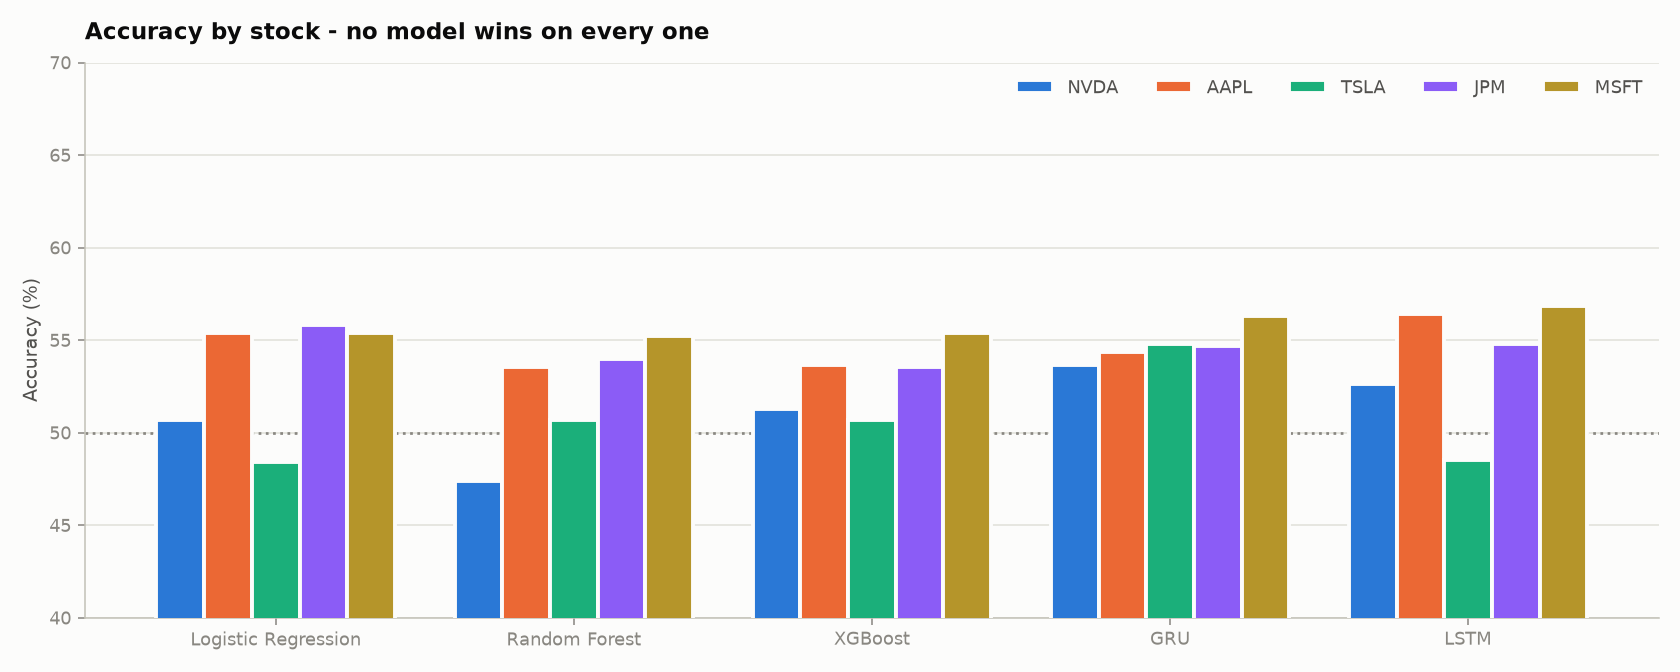

In [11]:
print(f"No model beats the always-UP baseline ({sel['baseline_overall']}%) overall,")
print('and every AUC sits between 50.0 and 51.1 - none of the five ranks days better')
print('than chance. That is the measurement that motivates the rest of the notebook:')
print('if architecture search on price history cannot clear the baseline, the open')
print('question is whether a different KIND of information can.')


def fig_by_stock(preds):
    """Accuracy per model per stock - does any one model win everywhere?"""
    models = [m for m in MODEL_ORDER if m in set(preds['model'])]
    ticks  = [t for t in C.TICKERS if t in set(preds['ticker'])]
    x, w = np.arange(len(models)), 0.8 / max(len(ticks), 1)

    fig, ax = plt.subplots(figsize=(12, 4.8))
    for i, tick in enumerate(ticks):
        vals = []
        for m in models:
            sub = preds[(preds['model'] == m) & (preds['ticker'] == tick)]
            pred = (sub['p_up'].values >= sub['threshold'].values).astype(int)
            vals.append(float((pred == sub['y_true'].values).mean()) * 100 if len(sub) else 0.0)
        bars = ax.bar(x + (i - (len(ticks) - 1) / 2) * w, vals, width=w,
                      color=TICKER_COLOUR[tick], label=tick, zorder=3)
        for b in bars:
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
    ax.axhline(50, color=MUTED, linewidth=1.4, linestyle=':', zorder=2)
    ax.set_xticks(x, models, fontsize=10, color=INK2)
    ax.set_ylim(40, 70)
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, ncol=len(ticks))
    style_axes(ax, title='Accuracy by stock - no model wins on every one', ylabel='Accuracy (%)')
    return save_fig(fig, 'model2_by_stock.png')


fig_by_stock(model_preds)
display(Image(filename=str(OUT / 'model2_by_stock.png')))

---
# 3. Evidence corpus and retrieval (RAG)

Mostly computed from the data rather than hand-written, which removes researcher judgement.
Retrieval is plain TF-IDF cosine so every step can be checked by hand. The look-ahead guard
(`item date <= query date`) is **tested**, not asserted.

In [12]:
items = E.build_corpus(bundle)
retriever = E.EvidenceRetriever(items)
by_type = Counter(i['type'] for i in items)
print(f"{len(items)} evidence items: {dict(by_type)}  "
      f"({by_type['macro'] / len(items) * 100:.0f}% hand-written)")

# What retrieval returns on a shock date
q = E.market_state_query(bundle, 'NVDA', '2020-03-20')
for it in retriever.retrieve(q, '2020-03-20'):
    print(f"  [{it['type']:5}] {it['date']}  score={it['score']:.3f}  {it['text'][:80]}")

252 evidence items: {'vix': 71, 'move': 156, 'macro': 25}  (10% hand-written)
  [macro] 2020-03-15  score=0.212  The Federal Reserve cuts rates to near zero and restarts large-scale asset purch
  [move ] 2020-03-16  score=0.120  The equal-weighted basket of the five stocks falls 14.9% in one session, an unus
  [vix  ] 2020-02-24  score=0.111  Market volatility rises above the stress threshold: the VIX closes at 25.0 again
  [macro] 2020-02-24  score=0.030  Equity markets fall sharply as coronavirus cases spread beyond China; volatility


In [13]:
# Look-ahead guard, tested rather than asserted
violations = checked = 0
dates = pd.date_range('2019-06-01', '2024-12-01', freq='90D')
for date in dates:
    for it in retriever.retrieve(E.market_state_query(bundle, 'NVDA', date), date):
        checked += 1
        violations += pd.Timestamp(it['date']) > date

print(f'Checked {checked} retrieved items across {len(dates)} dates')
print(f'Items dated AFTER their query date: {violations}')
assert violations == 0, 'Look-ahead detected in retrieval'
print('PASS - retrieval never returns an item from the future.')

Checked 48 retrieved items across 23 dates
Items dated AFTER their query date: 0
PASS - retrieval never returns an item from the future.


---
# 4. Arm 1 — ML (the selected LSTM)

A fixed function of its input: the same 60 days always produce the same number.

| Setting | Value |
|---|---|
| Architecture | LSTM(64) → LSTM(32) → Dense(16, ReLU) → Dense(1, sigmoid) |
| Input | 60 days × 22 features |
| Training | 40 epochs, batch 128, early stopping (patience 6), ReduceLROnPlateau |

Predictions are produced walk-forward: every test date is scored by a model trained only on data
from before it, with a 5-day gap between so no training label can overlap a test label.

In [14]:
if RUN_TRAINING:
    # Writes outputs/ml_predictions.csv, saved_models/lstm_fold*.keras and the
    # final model + scaler the live demo loads. ~10-20 min on a laptop CPU.
    M.train_and_predict(bundle)

ml_table = pd.read_csv(M.PRED_FILE)
ml_table['pred'] = (ml_table['p_up'] >= ml_table['threshold']).astype(int)

rows = [{'Regime': r, 'n': len(s),
         'ML accuracy %': round((s['pred'] == s['y_true']).mean() * 100, 2),
         'Always-UP %':   round(s['y_true'].mean() * 100, 2)}
        for r, s in ml_table.groupby('regime')]
rows.append({'Regime': 'ALL', 'n': len(ml_table),
             'ML accuracy %': round((ml_table['pred'] == ml_table['y_true']).mean() * 100, 2),
             'Always-UP %':   round(ml_table['y_true'].mean() * 100, 2)})
display(pd.DataFrame(rows))
print('The ML arm does NOT beat the always-UP baseline overall. Reported, not hidden.')

,Regime,n,ML accuracy %,Always-UP %
0,CALM,3660,53.96,55.38
1,SHOCK,720,53.19,52.92
2,ALL,4380,53.84,54.98


The ML arm does NOT beat the always-UP baseline overall. Reported, not hidden.


---
# 5. Arms 2 & 3 — the LLM, without and with evidence

Identical model, temperature, wording and output schema. The **only** difference is whether an
EVIDENCE section is present, so any difference between the two arms is attributable to retrieval.
Stock names are hidden (`Stock A`…`Stock E`) and prices rebased to 100, so the model cannot answer
from memory of what the company actually did.

In [15]:
ev = retriever.retrieve(E.market_state_query(bundle, 'NVDA', '2020-03-20'), '2020-03-20')
prompt, meta = L.build_prompt(bundle, 'NVDA', '2020-03-20', evidence=ev)
print(prompt)

You are a quantitative analyst. Predict whether this stock's closing price will be HIGHER in 5 trading days than it is now.

MARKET DATA (everything below is as of today; you cannot see the future)

Stock A (price history rebased so the first day = 100):
  Last 20 closes: 100.0, 95.9, 97.9, 92.5, 98.9, 101.2, 97.4, 104.2, 100.1, 97.4, 89.9, 95.6, 90.2, 79.2, 88.2, 71.9, 79.6, 74.3, 78.0, 75.3
  RSI(14), 0-1 scale: 0.402
  Return over last 5 days: -14.57%
  Return over last 20 days: -29.99%
  10-day volatility: 0.1001
  Volume vs its 20-day average: 1.07
  MACD ratio: -0.07343

RETRIEVED EVIDENCE (dated on or before today; this is the only outside information you have):
  [macro_2020-03-15] (2020-03-15) The Federal Reserve cuts rates to near zero and restarts large-scale asset purchases in an emergency weekend action.  -- source: Federal Reserve FOMC statement
  [move_2020-03-16] (2020-03-16) The equal-weighted basket of the five stocks falls 14.9% in one session, an unusually large dai

---
# 6. Arm 4 — Hybrid (calibrated logit pooling)

The two arms do not speak the same language: the LSTM only means UP above 0.59, the LLM above 0.60.
Averaging raw probabilities averages two different zero points — the first version of this fusion
did exactly that and scored **below both of its own parents** (53.7%).

```
z_arm = logit(p_arm) - logit(threshold_arm)     # signed distance from its OWN decision point
z_hyb = (1 - w) * z_ML + w * z_LLM_RAG
p_hyb = sigmoid(z_hyb)   ->  decide UP at 0.5
```

Both inputs are centred, so the hybrid decides at 0.5 by construction — **one fitted parameter fewer
than any arm it is compared against**. `w` is derived per regime from each arm's log-loss on the
tuning split, then shrunk halfway to an equal blend.

In [16]:
display(pd.DataFrame(
    [{'Parameter': 'Fusion method', 'Value': results['fusion']['method']},
     {'Parameter': 'Shrinkage to equal blend', 'Value': results['fusion']['shrink']}]
    + [{'Parameter': f'Weight on LLM ({r.lower()})', 'Value': v} for r, v in wts.items()]
    + [{'Parameter': f'Threshold {a}', 'Value': v} for a, v in th.items()]))

# One disagreement case, worked end to end
p_ml, p_llm, regime = 0.624, 0.300, 'SHOCK'
z_ml  = float(H.calibrate(p_ml, th['ML']))
z_llm = float(H.calibrate(p_llm, th['LLM_RAG']))
z = float(H.pool(z_ml, z_llm, wts[regime]))
print(f"\nML  p={p_ml} -> z={z_ml:+.3f} (UP)    LLM p={p_llm} -> z={z_llm:+.3f} (DOWN)")
print(f"pooled z = {z:+.3f} -> p = {H.sigmoid(z):.3f} -> "
      f"{'UP' if H.sigmoid(z) >= 0.5 else 'DOWN'}  (larger distance carries)")

,Parameter,Value
0,Fusion method,calibrated_logit_pool_v2
1,Shrinkage to equal blend,0.5
2,Weight on LLM (calm),0.492
3,Weight on LLM (shock),0.487
4,Threshold ML,0.59
5,Threshold LLM,0.6
6,Threshold LLM_RAG,0.6
7,Threshold HYBRID,0.5



ML  p=0.624 -> z=+0.143 (UP)    LLM p=0.3 -> z=-1.253 (DOWN)
pooled z = -0.537 -> p = 0.369 -> DOWN  (larger distance carries)


---
# 7. Backtest and evaluation

**Design of the sample.** Shock days are only about a fifth of the period, so a plain random sample
would put almost no weight on exactly the regime the research question is about. Dates are drawn
stratified: an equal number of calm and shock dates, spread evenly across the period rather than
randomly, so the sample is fully determined by the data and no seed is involved.

**Design of the split.** The earlier dates become the TUNING set, used only to choose the thresholds
and the hybrid weight. The later dates are the HOLDOUT, which is what every reported number comes
from. The split is chronological and **by date** rather than by row, because the five stocks share
each date and would otherwise leak across the boundary. Confidence intervals are bootstrapped by
date for the same reason.

In [17]:
N_DATES_PER_REGIME = 50     # 50 calm + 50 shock dates, x 5 stocks = 500 rows per arm
TUNING_FRACTION    = 0.40   # earliest 40% of sampled dates tune the hybrid weight
STABILITY_CASES    = 30     # how many cases get the repeat-run stability test
MAX_WORKERS        = 6      # parallel API calls; modest, to respect rate limits

RESULTS_CSV   = OUT / 'backtest_predictions.csv'
RESULTS_JSON  = OUT / 'results.json'
STABILITY_CSV = OUT / 'stability.csv'


def sample_dates(ml_table, n_per_regime=N_DATES_PER_REGIME):
    """Pick an equal number of calm and shock dates, spread across the period."""
    by_date = ml_table.groupby('date')['regime'].first()
    picked = []
    for regime in ('CALM', 'SHOCK'):
        dates = sorted(by_date[by_date == regime].index)
        if len(dates) <= n_per_regime:
            picked += dates
        else:
            # Spread across the period rather than clustering inside one episode.
            idx = np.linspace(0, len(dates) - 1, n_per_regime).round().astype(int)
            picked += [dates[i] for i in sorted(set(idx))]
    return sorted(picked)


def assemble(ml_table, llm_df):
    """Join the ML predictions to the two LLM arms on (date, ticker)."""
    ml = ml_table.copy()
    ml['pred_ML'] = (ml['p_up'] >= ml['threshold']).astype(int)
    ml = ml.rename(columns={'p_up': 'p_ML'})[
        ['date', 'ticker', 'regime', 'vix', 'y_true', 'p_ML', 'pred_ML']]
    wide = llm_df.pivot_table(index=['date', 'ticker'], columns='arm',
                              values='p_up', aggfunc='first').reset_index()
    wide.columns.name = None
    wide = wide.rename(columns={'LLM': 'p_LLM', 'LLM_RAG': 'p_LLM_RAG'})
    return ml.merge(wide, on=['date', 'ticker'], how='inner').dropna(
        subset=['p_LLM', 'p_LLM_RAG'])


def tune_threshold(p, y, lo=0.30, hi=0.70, step=0.01):
    """The cut-off that maximises accuracy on the rows given - TUNING rows only.

    Every arm gets this same treatment, which is what makes the comparison
    symmetric: no system is judged at a cut-off another one was allowed to
    optimise.
    """
    p, y = np.asarray(p, dtype=float), np.asarray(y)
    best_t, best_acc = 0.5, -1.0
    for t in np.arange(lo, hi + 1e-9, step):
        a = float(((p >= t).astype(int) == y).mean())
        if a > best_acc + 1e-12:
            best_acc, best_t = a, float(t)
    return round(best_t, 3)


def tune_and_evaluate(df, verbose=True):
    """Split by date, tune on the earlier part, report on the later.

    The order matters. A threshold is chosen for each of the three base arms
    first, because the hybrid's calibration step is defined relative to those
    thresholds. Only then is the fusion weight derived. The hybrid gets no
    threshold of its own: both inputs are already centred on their arm's line,
    so the pooled score decides at zero.
    """
    dates = sorted(df['date'].unique())
    cut = int(len(dates) * TUNING_FRACTION)
    tuning_dates, holdout_dates = set(dates[:cut]), set(dates[cut:])
    tune = df[df['date'].isin(tuning_dates)].copy()
    hold = df[df['date'].isin(holdout_dates)].copy()

    thresholds = {}
    for arm in ('ML', 'LLM', 'LLM_RAG'):
        t = tune_threshold(tune[f'p_{arm}'].values, tune['y_true'].values)
        thresholds[arm] = t
        for frame in (tune, hold):
            frame[f'pred_{arm}'] = (frame[f'p_{arm}'] >= t).astype(int)

    # Built on the GROUNDED LLM, so the hybrid and LLM_RAG are like-for-like.
    renamed = {'p_ML': 'p_ml', 'p_LLM_RAG': 'p_llm'}
    weights = H.tune_by_regime(tune.rename(columns=renamed), thresholds)
    thresholds['HYBRID'] = 0.5
    H.save_weights(weights, thresholds)

    for frame in (tune, hold):
        frame['p_HYBRID'] = H.apply_by_regime(frame.rename(columns=renamed), weights, thresholds)
        frame['pred_HYBRID'] = (frame['p_HYBRID'] >= 0.5).astype(int)
        # The same centring applied to every base arm, so the Brier scores
        # compare like with like rather than rewarding the hybrid for a step
        # the others never got.
        for arm in ('ML', 'LLM', 'LLM_RAG'):
            frame[f'cal_{arm}'] = H.sigmoid(H.calibrate(frame[f'p_{arm}'].values, thresholds[arm]))
        frame['cal_HYBRID'] = frame['p_HYBRID']

    if verbose:
        print(f'  tuning on {len(tuning_dates)} dates ({len(tune)} rows), '
              f'holdout {len(holdout_dates)} dates ({len(hold)} rows)')
        print(f'  tuned thresholds        : {thresholds}')
        print(f'  derived LLM trust weight: {weights}  (shrink={C.HYBRID_SHRINK})')
    return hold, weights, tune, thresholds


print('Backtest helpers defined.')

Backtest helpers defined.


### Running the arms

The LLM calls are the expensive part — roughly 1,000 requests plus 150 for the stability test. With
`RUN_BACKTEST = False` the notebook reads the saved run; the code below is what produced it.
Responses are cached in `data/cache/llm_cache.json`, so a re-run costs nothing for cases already
seen.

In [18]:
from concurrent.futures import ThreadPoolExecutor, as_completed


def run_llm_arms(bundle, retriever, dates, tickers=None, verbose=True):
    """Call both LLM arms for every (ticker, date). Returns a tidy DataFrame."""
    tickers = tickers or C.TICKERS
    arm = L.LLMArm(bundle, retriever)
    jobs = [(t, d, rag) for d in dates for t in tickers for rag in (False, True)]
    if verbose:
        print(f'  {len(jobs)} LLM calls ({len(dates)} dates x {len(tickers)} stocks x 2 arms)')

    def one(ticker, date, use_rag):
        try:
            return ticker, date, arm.predict(ticker, date, use_rag=use_rag)
        except Exception as exc:
            return ticker, date, {'_error': str(exc)}

    rows, errors = [], 0
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = [pool.submit(one, t, d, rag) for t, d, rag in jobs]
        for fut in as_completed(futures):
            ticker, date, res = fut.result()
            if res is None or '_error' in (res or {}):
                errors += 1
                continue
            audit = V.audit(res, ticker)
            rows.append({
                'date': date, 'ticker': ticker, 'arm': res['arm'], 'p_up': res['p_up'],
                'direction': res['direction'], 'confidence': res['confidence'],
                'reasoning': res['reasoning'],
                'n_evidence': len(res.get('evidence') or []),
                'n_cited':    len(res.get('evidence_cited') or []),
                'hallucinated_number': audit['numbers']['hallucinated'],
                'unit_errors':         audit['numbers']['n_unit_errors'],
                'fabricated_citation': bool(audit['groundedness'].get('hallucinated')),
                'grounded':            bool(audit['groundedness'].get('grounded')),
                'identity_leaked':     bool(audit['anonymity'].get('leaked')),
                'audit_clean':         audit['clean'],
                'audit_verdict':       audit['verdict'],
            })
    L.flush_cache()
    if verbose:
        print(f'  {len(rows)} responses collected, {errors} failed')
    return pd.DataFrame(rows)


def run_stability(bundle, retriever, ml_rows, n_cases=STABILITY_CASES, verbose=True):
    """Repeat the identical prompt on a sample of cases and record the disagreement."""
    arm = L.LLMArm(bundle, retriever)
    rng = np.random.default_rng(C.RAND_SEED)
    cases = []
    for regime in ('CALM', 'SHOCK'):
        sub = ml_rows[ml_rows['regime'] == regime]
        dates = sorted(sub['date'].unique())
        for d in rng.choice(dates, size=min(n_cases // 2, len(dates)), replace=False):
            cases.append((rng.choice(C.TICKERS), str(d), regime))
    if verbose:
        print(f'  stability: {len(cases)} cases x {C.SELF_CONSISTENCY_RUNS} repeats')

    # The ML probability is a fixed function of its input, so one value covers all
    # repeats - and having it here is what lets the hybrid be reconstructed later
    # without asking the model anything again.
    ml_lookup = ml_rows.set_index(['date', 'ticker'])['p_up'].to_dict()

    rows = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futs = {pool.submit(arm.self_consistency, t, d, True): (t, d, r) for t, d, r in cases}
        for fut in as_completed(futs):
            ticker, date, regime = futs[fut]
            try:
                cons = fut.result()
            except Exception:
                continue
            if cons is None:
                continue
            rows.append({'date': date, 'ticker': ticker, 'regime': regime,
                         'runs': cons['runs'], 'agreement': cons['agreement'],
                         'flipped': cons['flipped'], 'p_mean': cons['p_mean'],
                         'p_std': cons['p_std'],
                         'directions': '|'.join(cons['directions']),
                         'probs': '|'.join(f'{p:.6f}' for p in cons['probs']),
                         'p_ml': ml_lookup.get((date, ticker))})
    L.flush_cache()
    return pd.DataFrame(rows)


if RUN_BACKTEST:
    dates = sample_dates(ml_table)
    print(f'Sampled {len(dates)} dates')
    llm_df = run_llm_arms(bundle, retriever, dates)
    llm_df.to_csv(OUT / 'llm_responses.csv', index=False)

    stab_df = run_stability(bundle, retriever, ml_table[ml_table['date'].isin(dates)])
    stab_df.to_csv(STABILITY_CSV, index=False)

    hold, weights, tune, thresholds = tune_and_evaluate(assemble(ml_table, llm_df))
    pd.concat([tune.assign(split='tuning'), hold.assign(split='holdout')]).to_csv(
        RESULTS_CSV, index=False)
else:
    llm_df  = pd.read_csv(OUT / 'llm_responses.csv')
    stab_df = pd.read_csv(STABILITY_CSV)

preds = pd.read_csv(RESULTS_CSV)
hold  = preds[preds['split'] == 'holdout']
print(f"{len(preds)} rows on file, {len(hold)} of them holdout "
      f"across {hold['date'].nunique()} dates")

500 rows on file, 300 of them holdout across 60 dates


### Accuracy, calibration and the paired tests

,System,Overall %,CALM %,SHOCK %,95% CI,Brier (raw),Brier (cal)
0,Hybrid (ML + RAG-LLM),58.33,57.89,59.09,"[52.33, 64.67]",0.2447,0.2447
1,LLM + RAG (grounded),57.67,56.32,60.00,"[51.0, 64.33]",0.2446,0.2505
2,LLM only (no evidence),56.00,55.79,56.36,"[49.66, 62.67]",0.2517,0.2509
3,ML only (LSTM),52.67,55.79,47.27,"[46.33, 59.33]",0.2542,0.2507
4,Baseline: always UP,54.33,54.21,54.55,-,-,-


Brier (cal) re-centres every arm on its own threshold, so the calibration
comparison is like-for-like rather than a free gift to the hybrid.


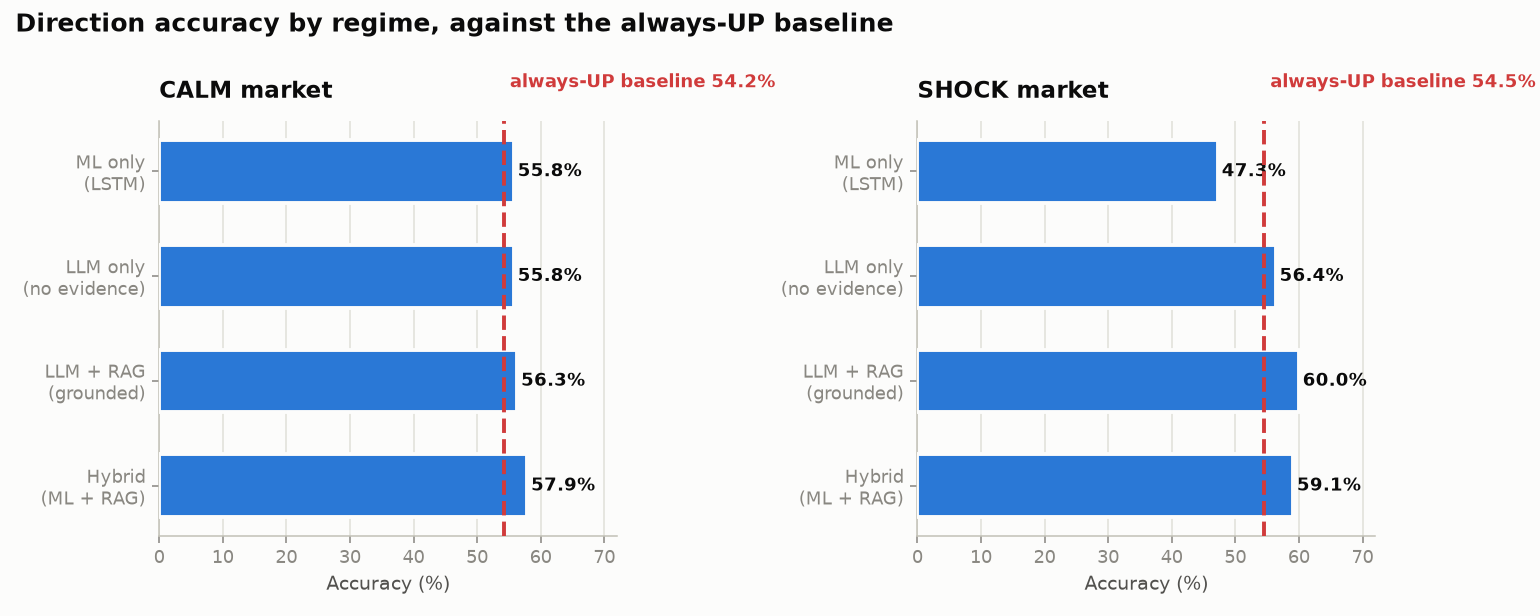

In [19]:
display(pd.DataFrame([{
    'System':      C.ARM_LABELS.get(a, 'Baseline: always UP'),
    'Overall %':   acc[a]['overall'],
    'CALM %':      acc[a].get('calm'),
    'SHOCK %':     acc[a].get('shock'),
    '95% CI':      f"[{acc[a]['ci'][0]}, {acc[a]['ci'][1]}]" if 'ci' in acc[a] else '-',
    'Brier (raw)': results['brier'].get(a, '-'),
    'Brier (cal)': results['brier_calibrated'].get(a, '-'),
} for a in ['HYBRID', 'LLM_RAG', 'LLM', 'ML', 'BASELINE_ALWAYS_UP']]))

print('Brier (cal) re-centres every arm on its own threshold, so the calibration')
print('comparison is like-for-like rather than a free gift to the hybrid.')


def fig_accuracy(results):
    """Accuracy by arm, faceted by regime. One hue; the baseline is a reference line."""
    a = results['accuracy']
    order = ['ML', 'LLM', 'LLM_RAG', 'HYBRID']
    short = {'ML': 'ML only\n(LSTM)', 'LLM': 'LLM only\n(no evidence)',
             'LLM_RAG': 'LLM + RAG\n(grounded)', 'HYBRID': 'Hybrid\n(ML + RAG)'}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
    for ax, regime in zip(axes, ('calm', 'shock')):
        vals = [a[k][regime] for k in order]
        base = a['BASELINE_ALWAYS_UP'][regime]
        y = np.arange(len(order))
        bars = ax.barh(y, vals, height=0.6, color=BLUE, zorder=3)
        for b in bars:
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
        ax.axvline(base, color=CRITICAL, linewidth=2, linestyle='--', zorder=4)
        ax.text(base, -0.85, f' always-UP baseline {base:.1f}%', color=CRITICAL,
                fontsize=9, fontweight='600', va='center')
        for i, v in enumerate(vals):
            ax.text(v + 0.6, i, f'{v:.1f}%', va='center', fontsize=9.5,
                    color=INK, fontweight='600')
        ax.set_yticks(y, [short[k] for k in order], fontsize=9, color=INK2)
        ax.invert_yaxis()
        ax.set_xlim(0, max(max(vals), base) + 12)
        style_axes(ax, title=f'{regime.upper()} market', xlabel='Accuracy (%)', grid_axis='x')
    fig.suptitle('Direction accuracy by regime, against the always-UP baseline',
                 color=INK, fontsize=13, fontweight='650', x=0.01, ha='left')
    return save_fig(fig, 'fig1_accuracy.png')


fig_accuracy(results)
display(Image(filename=str(OUT / 'fig1_accuracy.png')))

In [20]:
# Exact paired McNemar - only rows where two systems disagree carry information
seen, rows = set(), []
for key, m in results['mcnemar'].items():
    a_, b_ = key.replace('_CALM', '').replace('_SHOCK', '').split('_vs_')
    reg = 'calm' if key.endswith('_CALM') else 'shock' if key.endswith('_SHOCK') else 'overall'
    if (frozenset((a_, b_)), reg) in seen:
        continue
    seen.add((frozenset((a_, b_)), reg))
    rows.append({'Comparison': f'{a_} vs {b_}', 'Rows': reg, 'A only': m['n10'],
                 'B only': m['n01'], 'p (exact)': round(m['p'], 4),
                 'p<0.05': 'yes' if m['p'] < 0.05 else 'no'})
display(pd.DataFrame(rows))
print('Nothing clears 5%. Strongest signal: grounded-LLM vs ML in shocks (p=0.08).')

,Comparison,Rows,A only,B only,p (exact),p<0.05
0,ML vs LLM,overall,53,63,0.4035,no
1,ML vs LLM,calm,36,36,1.0000,no
2,ML vs LLM,shock,17,27,0.1742,no
3,ML vs LLM_RAG,overall,60,75,0.2281,no
4,ML vs LLM_RAG,calm,39,40,1.0000,no
5,ML vs LLM_RAG,shock,21,35,0.0814,no
6,ML vs HYBRID,overall,35,52,0.0857,no
7,ML vs HYBRID,calm,18,22,0.6358,no
8,ML vs HYBRID,shock,17,30,0.0789,no
9,HYBRID vs LLM,overall,59,52,0.5692,no


Nothing clears 5%. Strongest signal: grounded-LLM vs ML in shocks (p=0.08).


### What did each layer actually contribute?

Four accuracies give an ordering. They cannot say the layers *caused* it: a layer that fixes forty
rows and breaks forty lands in exactly the same place as one that does nothing. Each arm is
therefore compared with the arm directly beneath it on the same rows, counting only the rows the two
disagree on - the same argument that makes McNemar the right test above, applied to attribution
rather than significance.

In [ ]:
ladder = V.layer_contribution(preds[preds['split'] == 'holdout'])
ladder['quality'] = {a: results['response_quality']['scores'][a]['total'] for a in C.ARMS}

display(pd.DataFrame(ladder['steps']).rename(columns={
    'adds': 'Layer added', 'fixes': 'Rows fixed', 'breaks': 'Rows broken',
    'touched': 'Rows changed', 'net': 'Net', 'delta_pts': 'Accuracy gain (pts)',
})[['Layer added', 'Rows fixed', 'Rows broken', 'Rows changed', 'Net', 'Accuracy gain (pts)']])

print(f"Every layer nets positive: {ladder['monotone']}")
print(f"Each layer changes far more than it nets - retrieval alters "
      f"{ladder['steps'][1]['touched']} of {ladder['n']} rows to gain "
      f"{ladder['steps'][1]['net']}.")
print(f"Every layer helped on {ladder['ladder_rows']} rows and hurt on "
      f"{ladder['reverse_rows']}: a tendency across the holdout, not a property of a row.")

results['layer_contribution'] = ladder
(OUT / 'results.json').write_text(json.dumps(results, indent=2), encoding='utf-8')


def fig_ladder(ladder, results):
    """The ladder on both axes: accuracy left, response quality right.

    Two panels rather than two figures because the claim is that the SAME ordering
    holds on both, and a reader cannot check that across a page turn. The left
    panel is the weak version of the claim - 5.66 points, every interval
    overlapping - and the right is the strong one, so they belong side by side.
    """
    order = ['ML', 'LLM', 'LLM_RAG', 'HYBRID']
    names = ['ML only\n(LSTM)', 'LLM only\n(no evidence)',
             'LLM + RAG\n(grounded)', 'Hybrid\n(ML + RAG-LLM)']
    # The layer goes on the arrow, not under a bar: it is what happens BETWEEN two
    # arms, and labelling a bar with it invites reading "retrieved evidence" as a
    # system rather than a step.
    layers = [s['adds'].lower() for s in ladder['steps']]
    colours = [MUTED, AQUA, ORANGE, BLUE]

    fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))
    x = np.arange(4)

    def rungs(ax, vals, deltas, fmt, headroom, gap):
        for i, (d, layer) in enumerate(zip(deltas, layers)):
            top = max(vals[i], vals[i + 1])
            ax.annotate('', xy=(i + .80, vals[i + 1] + gap), xytext=(i + .20, vals[i] + gap),
                        arrowprops=dict(arrowstyle='->', color=INK2, linewidth=1.1))
            ax.text(i + .5, top + headroom, fmt.format(d), ha='center', fontsize=9.2,
                    fontweight='700', color=INK2)
            ax.text(i + .5, top + headroom * 1.62, layer, ha='center', fontsize=8.2, color=MUTED)

    acc = [ladder['accuracy'][a] for a in order]
    base = results['accuracy']['BASELINE_ALWAYS_UP']['overall']
    ax = axes[0]
    ax.bar(x, acc, color=colours, width=.6, zorder=3)
    for i, v in enumerate(acc):
        ax.text(i, v + .3, f'{v:.2f}%', ha='center', fontsize=10.5, fontweight='700',
                color=INK, zorder=4)
    ax.axhline(base, color=CRITICAL, linestyle='--', linewidth=1.2, zorder=2)
    ax.text(-.44, base, f'always UP  {base:.2f}%', ha='left', va='center', fontsize=8.4,
            color=CRITICAL, fontweight='600', zorder=4,
            bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1.4))
    rungs(ax, acc, [s['delta_pts'] for s in ladder['steps']], '+{:.2f} pts',
          headroom=2.0, gap=1.35)
    ax.set_ylim(44, 64.5)
    ax.set_xticks(x, names, fontsize=8.8, color=INK2)
    style_axes(ax, title='Direction accuracy  (300 holdout predictions)', ylabel='% correct')

    qual = [ladder['quality'][a] for a in order]
    ax = axes[1]
    ax.bar(x, qual, color=colours, width=.6, zorder=3)
    for i, v in enumerate(qual):
        ax.text(i, v + 1.1, f'{v:.1f}', ha='center', fontsize=10.5, fontweight='700',
                color=INK, zorder=4)
    rungs(ax, qual, [qual[i + 1] - qual[i] for i in range(3)], '+{:.1f}',
          headroom=7.0, gap=4.4)
    ax.set_ylim(0, 108)
    ax.set_xticks(x, names, fontsize=8.8, color=INK2)
    style_axes(ax, title='Response quality as a trading assistant  (out of 100)', ylabel='score')
    return save_fig(fig, 'fig7_ladder.png')


fig_ladder(ladder, results)
display(Image(filename=str(OUT / 'fig7_ladder.png')))

### How high can this task go?

Three bounds, in increasing order of unfairness. The oracle is the one that settles the question: it
cannot be built — it needs the answer to produce the answer — and it still cannot reach 85%, because
on some rows every arm is wrong at once. That bounds what any amount of further work on the fusion
could achieve without changing the arms themselves.

In [21]:
def ceiling_analysis(preds):
    """How high this task can go, including by cheating."""
    hold = preds[preds['split'] == 'holdout'].copy()
    y = hold['y_true'].values
    n = len(y)

    def a_(pred):
        return round(float((np.asarray(pred) == y).mean()) * 100, 2)

    thresholds = H.load_thresholds()
    arms = ('ML', 'LLM', 'LLM_RAG')

    honest = {k: a_((hold[f'p_{k}'] >= float(thresholds.get(k, 0.5))).astype(int)) for k in arms}
    honest['HYBRID'] = a_((hold['p_HYBRID'] >= 0.5).astype(int))

    # --- cheating 1: each arm's own threshold refitted on the holdout
    refit = {k: max(a_((hold[f'p_{k}'] >= t).astype(int)) for t in np.arange(0.05, 0.96, 0.01))
             for k in arms}

    # --- cheating 2: best three-arm logit blend, weights and cut on the holdout
    z = {k: H.logit(hold[f'p_{k}'].values) for k in arms}
    best_blend, best_at = 0.0, None
    for w1 in np.arange(0, 1.001, 0.05):
        for w2 in np.arange(0, 1.001 - w1, 0.05):
            w3 = 1.0 - w1 - w2
            sc = w1 * z['ML'] + w2 * z['LLM'] + w3 * z['LLM_RAG']
            for cut in np.arange(-1.5, 1.51, 0.05):
                v = a_((sc >= cut).astype(int))
                if v > best_blend:
                    best_blend = v
                    best_at = {'w_ml': round(float(w1), 2), 'w_llm': round(float(w2), 2),
                               'w_llm_rag': round(float(w3), 2), 'cut': round(float(cut), 2)}

    # --- the oracle: per row, believe whichever arm happens to be right
    by_arm = {k: (hold[f'p_{k}'] >= float(thresholds.get(k, 0.5))).astype(int).values for k in arms}
    by_arm['HYBRID'] = (hold['p_HYBRID'] >= 0.5).astype(int).values
    any_right = np.zeros(n, dtype=bool)
    for p in by_arm.values():
        any_right |= (p == y)

    return {'n_holdout': int(n), 'honest': honest, 'refit_on_holdout': refit,
            'best_blend_fitted_on_holdout': round(best_blend, 2), 'best_blend_at': best_at,
            'oracle_best_arm_per_row': round(float(any_right.mean()) * 100, 2),
            'all_arms_wrong_pct': round(float((~any_right).mean()) * 100, 2),
            'baseline_always_up': round(float(y.mean()) * 100, 2),
            'baseline_always_down': round(float(1 - y.mean()) * 100, 2)}


ceil = ceiling_analysis(preds)
(OUT / 'ceiling.json').write_text(json.dumps(ceil, indent=1), encoding='utf-8')

display(pd.DataFrame([
    {'Bound': 'Always predict UP', 'Acc %': ceil['baseline_always_up'], 'Fair?': 'baseline'},
    {'Bound': 'Reported hybrid', 'Acc %': ceil['honest']['HYBRID'], 'Fair?': 'YES'},
    {'Bound': 'Best blend fitted ON the holdout', 'Acc %': ceil['best_blend_fitted_on_holdout'],
     'Fair?': 'no - fitted on test set'},
    {'Bound': 'Oracle: per row, believe whichever arm is right',
     'Acc %': ceil['oracle_best_arm_per_row'], 'Fair?': 'impossible'},
]))
print(f"On {ceil['all_arms_wrong_pct']}% of rows all four arms are wrong at once, so even the")
print(f"oracle tops out at {ceil['oracle_best_arm_per_row']}%. A reported accuracy above that")
print('would indicate a look-ahead leak or test-set tuning, not a better model.')

,Bound,Acc %,Fair?
0,Always predict UP,54.33,baseline
1,Reported hybrid,58.33,YES
2,Best blend fitted ON the holdout,60.33,no - fitted on test set
3,"Oracle: per row, believe whichever arm is right",82.67,impossible


On 17.33% of rows all four arms are wrong at once, so even the
oracle tops out at 82.67%. A reported accuracy above that
would indicate a look-ahead leak or test-set tuning, not a better model.


---
# 8. Hallucination audit

Three mechanical checks on all 1,000 responses. No human rated anything: each check compares
something the model *said* against something the pipeline already *knows* — the figures it was
shown, the evidence ids it was given, and the identity it was not told.

,responses,fabricated figure %,unit error %,invented citation %,properly grounded %,named real company %,fully clean %
LLM,500.0,0.0,2.6,0.0,0.0,0.0,97.4
LLM_RAG,500.0,0.0,14.2,0.0,38.4,0.0,85.8


Zero fabricated figures and zero invented citations in 1,000 responses. The one
failure that appears - restating a number at the wrong scale - got WORSE with
retrieval (14.2% vs 2.6%): more context meant more numbers to keep straight.


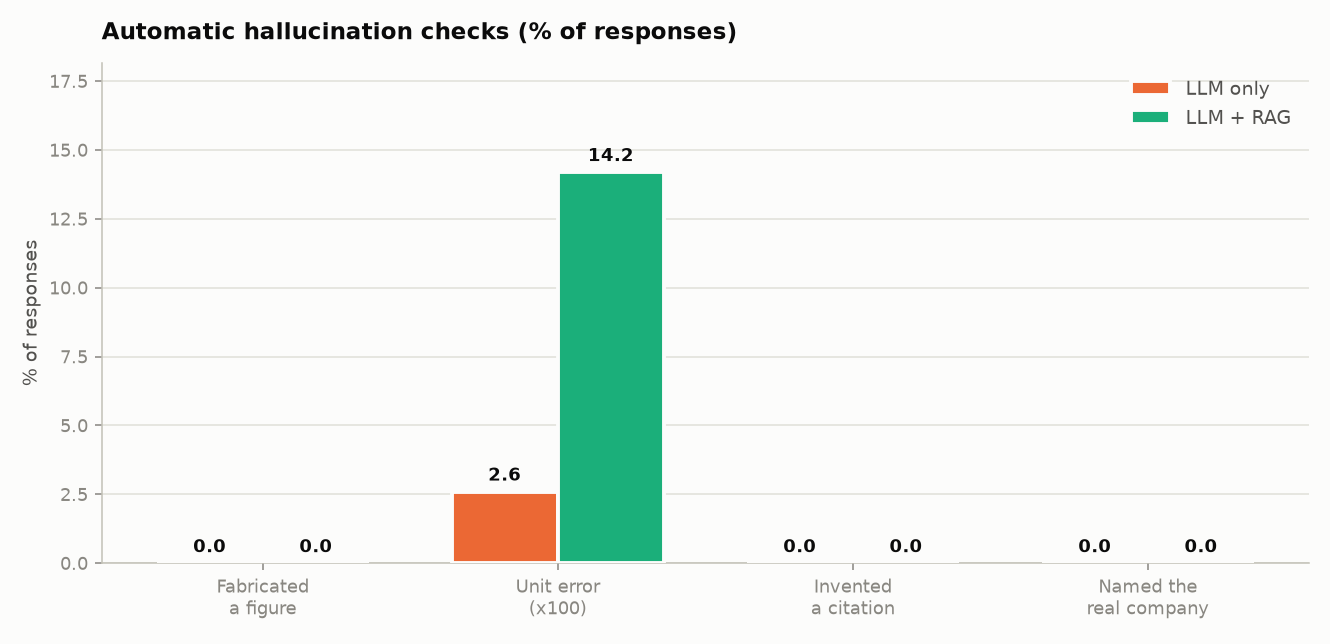

In [22]:
h = results['hallucination']
display(pd.DataFrame(h).T.rename(columns={
    'n': 'responses', 'fabricated_number_pct': 'fabricated figure %',
    'unit_error_pct': 'unit error %', 'fabricated_citation_pct': 'invented citation %',
    'grounded_pct': 'properly grounded %', 'identity_leak_pct': 'named real company %',
    'clean_pct': 'fully clean %'}))
print('Zero fabricated figures and zero invented citations in 1,000 responses. The one')
print('failure that appears - restating a number at the wrong scale - got WORSE with')
print('retrieval (14.2% vs 2.6%): more context meant more numbers to keep straight.')


def fig_hallucination(results):
    """How often each LLM arm got something factually wrong."""
    h = results.get('hallucination', {})
    if 'LLM' not in h or 'LLM_RAG' not in h:
        return None
    metrics = [('fabricated_number_pct',   'Fabricated\na figure'),
               ('unit_error_pct',          'Unit error\n(x100)'),
               ('fabricated_citation_pct', 'Invented\na citation'),
               ('identity_leak_pct',       'Named the\nreal company')]
    x, w = np.arange(len(metrics)), 0.36
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    for i, (arm, colour, label) in enumerate([('LLM', ORANGE, 'LLM only'),
                                              ('LLM_RAG', AQUA, 'LLM + RAG')]):
        vals = [h[arm].get(k, 0) for k, _ in metrics]
        bars = ax.bar(x + (i - 0.5) * w, vals, width=w, color=colour, label=label, zorder=3)
        for b in bars:
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
        for xi, v in zip(x + (i - 0.5) * w, vals):
            ax.text(xi, v + 0.4, f'{v:.1f}', ha='center', fontsize=9, color=INK, fontweight='600')
    ax.set_xticks(x, [lab for _, lab in metrics], fontsize=9.5, color=INK2)
    ax.legend(frameon=False, fontsize=10, labelcolor=INK2)
    style_axes(ax, title='Automatic hallucination checks (% of responses)',
               ylabel='% of responses')
    ax.set_ylim(0, max(1, max(max(h['LLM'].get(k, 0), h['LLM_RAG'].get(k, 0))
                              for k, _ in metrics)) * 1.28)
    return save_fig(fig, 'fig2_hallucination.png')


fig_hallucination(results)
display(Image(filename=str(OUT / 'fig2_hallucination.png')))

---
# 9. Stability

The objection to comparing an LSTM with an LLM is that one is deterministic and the other is not, so
a single LLM accuracy figure is a sample rather than a property. The answer is to measure it: the
identical prompt, five times, at temperature 0.

,System,Answer changed %,Mean sd of p(up)
0,ML only (LSTM),0.00,0.0000
1,LLM + RAG,3.33,0.0079
2,Hybrid,3.33,0.0040


findfont: Failed to find font weight 650, now using 700.


Flip rate by regime: {'CALM': 0.0, 'SHOCK': 6.67}   (cases=30, repeats=5)


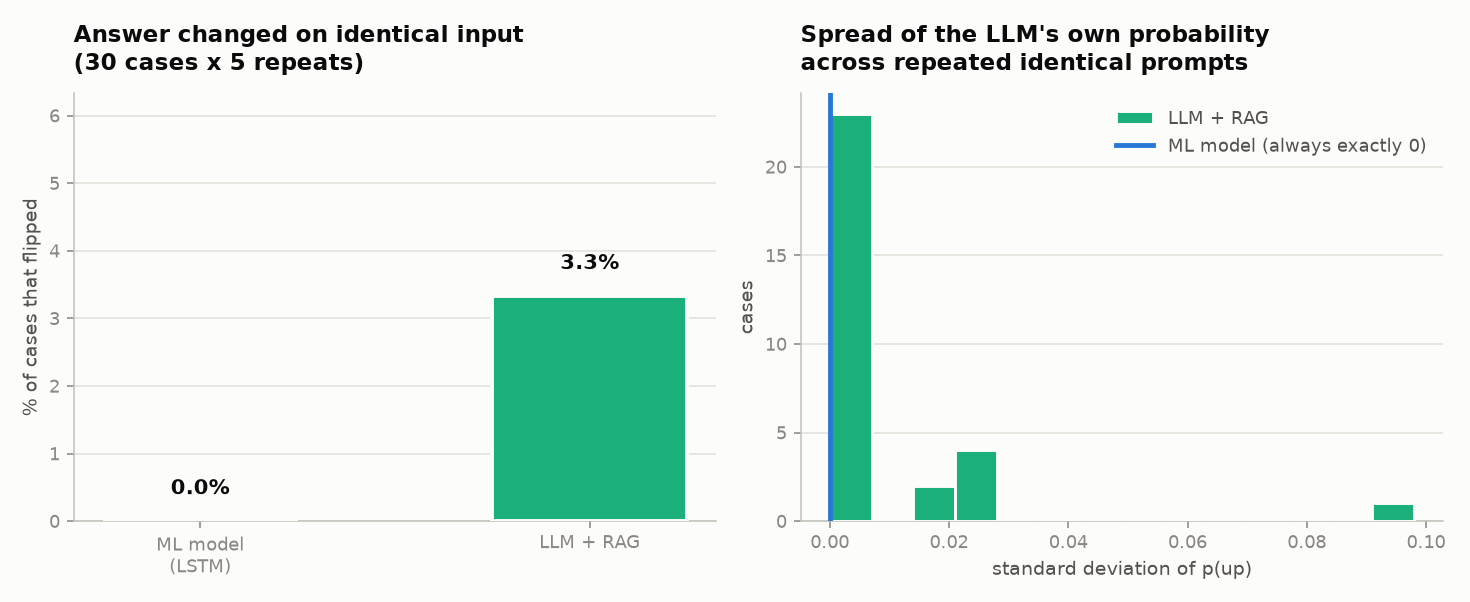

In [23]:
s   = results['stability']
hyb = results['stability'].get('hybrid', {})

display(pd.DataFrame([
    {'System': 'ML only (LSTM)', 'Answer changed %': 0.0, 'Mean sd of p(up)': 0.0},
    {'System': 'LLM + RAG', 'Answer changed %': s['flip_rate_pct'],
     'Mean sd of p(up)': s['mean_p_std']},
    {'System': 'Hybrid', 'Answer changed %': hyb.get('flip_rate_pct'),
     'Mean sd of p(up)': hyb.get('mean_p_std')},
]))
print(f"Flip rate by regime: {s.get('by_regime')}   (cases={s['n_cases']}, "
      f"repeats={s['runs_per_case']})")


def fig_stability(results, stab):
    """The determinism comparison: how often each system contradicts itself."""
    s = results.get('stability', {})
    if not s:
        return None
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

    ax = axes[0]
    vals = [0.0, s['flip_rate_pct']]
    bars = ax.bar(['ML model\n(LSTM)', 'LLM + RAG'], vals, width=0.5,
                  color=[BLUE, AQUA], zorder=3)
    for b in bars:
        b.set_linewidth(2)
        b.set_edgecolor(SURFACE)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.03 + 0.3, f'{v:.1f}%', ha='center',
                fontsize=11, color=INK, fontweight='650')
    ax.set_ylim(0, max(vals) * 1.3 + 2)
    style_axes(ax, title=f"Answer changed on identical input\n"
                         f"({s['n_cases']} cases x {s['runs_per_case']} repeats)",
               ylabel='% of cases that flipped')

    ax = axes[1]
    if stab is not None and len(stab):
        ax.hist(stab['p_std'], bins=14, color=AQUA, zorder=3, edgecolor=SURFACE,
                linewidth=1.5, label='LLM + RAG')
        ax.axvline(0, color=BLUE, linewidth=2.5, zorder=4, label='ML model (always exactly 0)')
        ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, loc='upper right')
    style_axes(ax, title='Spread of the LLM\'s own probability\nacross repeated identical prompts',
               xlabel='standard deviation of p(up)', ylabel='cases')
    return save_fig(fig, 'fig3_stability.png')


fig_stability(results, stab_df)
display(Image(filename=str(OUT / 'fig3_stability.png')))

In [24]:
# Does the hybrid inherit the ML arm's determinism? Tested, not assumed.
display(stab_df[stab_df['flipped']][['date', 'ticker', 'regime', 'directions', 'p_std']])
print(f"Hybrid moves {hyb.get('p_std_vs_llm')}x as much as the LLM   -> variance IS damped")
print(f"Hybrid flip rate {hyb.get('flip_rate_pct')}% vs LLM {s['flip_rate_pct']}%  -> identical")
print(f"Flipped where the LLM did NOT: {hyb.get('flipped_where_llm_did_not')}")
print('\nH3 second clause NOT supported: blending damps the SIZE of a disagreement, not')
print('the FACT of one. Halving the movement does not help when a case already sits on')
print('the decision boundary - which is exactly where a flip happens.')
print('\nCAVEAT: the flip-rate figure rests on a single case. Treat as indicative.')

,date,ticker,regime,directions,p_std
20,2022-05-06,TSLA,SHOCK,UP|UP|DOWN|DOWN|DOWN,0.09798


Hybrid moves 0.505x as much as the LLM   -> variance IS damped
Hybrid flip rate 3.33% vs LLM 3.33%  -> identical
Flipped where the LLM did NOT: 0

H3 second clause NOT supported: blending damps the SIZE of a disagreement, not
the FACT of one. Halving the movement does not help when a case already sits on
the decision boundary - which is exactly where a flip happens.

CAVEAT: the flip-rate figure rests on a single case. Treat as indicative.


---
# 10. Response quality — scoring the arms as *assistants*

Direction accuracy answers "was the call right". For a trading assistant that is not the whole
question, and on a 5-day horizon it is barely answerable at all — every arm lands between 52% and
59%, inside each other's confidence intervals. But a user does not only consume the call. They
consume an *answer*: a direction, a reason, some evidence, and a recommendation shaped to their risk
appetite. For a trading assistant a confident, unverifiable, unhedged answer is the expensive
failure, not a coin flip that landed badly.

| Dimension | Points | Question it asks |
|---|---|---|
| Grounding | 30 | can every claim be traced to something it was given? |
| Personalisation | 25 | is the advice shaped to this user and this situation? |
| Helpfulness | 25 | can the user understand and act on it? |
| Safety | 20 | does it avoid the failure modes that cost money? |

Scored mechanically from the saved responses. No human rates anything and no LLM judges anything —
a judge would import the same non-determinism section 9 measures, and would not be reproducible. The
weights are set once, on the argument written next to each rule, and are **not** tuned to produce any
particular ranking.

In [25]:
# Language a trading assistant should never use. Absolute certainty about a
# future price is the single most expensive thing one of these can say.
ABSOLUTIST = re.compile(
    r'\b(?:guarantee\w*|certainly|definitely|no risk|risk[- ]free|sure thing|'
    r'will surely|cannot lose|assured|undoubtedly|without a doubt)\b', re.I)

# Words that show the answer engaged with the market state rather than the chart
# in isolation - the thing an LLM is supposed to add over the LSTM.
SITUATIONAL = re.compile(
    r'\b(?:volatil\w*|vix|market|macro|inflation|fed|rate\w*|shock|stress\w*|'
    r'uncertain\w*|sentiment|news|environment|condition\w*|economic)\b', re.I)

MAXIMA = {'grounding': 30, 'personalisation': 25, 'helpfulness': 25, 'safety': 20}


def _num(v, default=0):
    try:
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return default
        return float(v)
    except (TypeError, ValueError):
        return default


def build_responses(preds, llm_df, thresholds, weights):
    """One row per (case, arm): the response that arm would actually have given.

    The hybrid inherits the grounded arm's evidence and reasoning. That is a claim
    about the deployed system, not a scoring convenience: app.py renders the
    retrieved evidence and the RAG reasoning alongside every hybrid answer.
    """
    hold = preds[preds['split'] == 'holdout'].copy()
    wide = llm_df.pivot_table(index=['date', 'ticker'], columns='arm',
                              values=['reasoning', 'n_evidence', 'n_cited',
                                      'hallucinated_number', 'unit_errors',
                                      'fabricated_citation', 'grounded'], aggfunc='first')
    wide.columns = [f'{a}__{b}' for a, b in wide.columns]
    hold = hold.merge(wide.reset_index(), on=['date', 'ticker'], how='left')

    rows = []
    for _, r in hold.iterrows():
        rag_text = r.get('reasoning__LLM_RAG')
        rag_text = rag_text if isinstance(rag_text, str) else ''
        llm_text = r.get('reasoning__LLM')
        llm_text = llm_text if isinstance(llm_text, str) else ''

        w = float(weights.get(r['regime'], 0.5))
        z_ml  = float(H.calibrate(r['p_ML'], float(thresholds.get('ML', 0.5))))
        z_llm = float(H.calibrate(r['p_LLM_RAG'], float(thresholds.get('LLM_RAG', 0.5))))
        agree = (z_ml >= 0) == (z_llm >= 0)
        fusion_text = (
            f"The ML model reads {z_ml:+.2f} from its own decision point and the grounded "
            f"LLM {z_llm:+.2f}; in a {r['regime'].lower()} market the derived trust in the "
            f"LLM is {w:.2f}. "
            + ('Both components agree, so the blend only sharpens the confidence.' if agree else
               'The two components disagree, so the larger distance decides and the '
               'confidence is reduced accordingly.'))

        def p_to_conf(p, t):
            return p if p >= t else 1.0 - p

        common = {'date': r['date'], 'ticker': r['ticker'], 'regime': r['regime']}
        rows.append({**common, 'arm': 'ML',
                     'confidence': p_to_conf(r['p_ML'], float(thresholds.get('ML', .5))),
                     'text': '', 'model_text': '', 'n_evidence': 0, 'n_cited': 0,
                     'fabricated_number': 0, 'unit_errors': 0, 'fabricated_citation': 0,
                     'grounded': 0, 'reports_conflict': 0})
        rows.append({**common, 'arm': 'LLM',
                     'confidence': p_to_conf(r['p_LLM'], float(thresholds.get('LLM', .5))),
                     'text': llm_text, 'model_text': llm_text, 'n_evidence': 0,
                     'n_cited': _num(r.get('n_cited__LLM')),
                     'fabricated_number': _num(r.get('hallucinated_number__LLM')),
                     'unit_errors': _num(r.get('unit_errors__LLM')),
                     'fabricated_citation': _num(r.get('fabricated_citation__LLM')),
                     'grounded': 0, 'reports_conflict': 0})
        rows.append({**common, 'arm': 'LLM_RAG',
                     'confidence': p_to_conf(r['p_LLM_RAG'],
                                             float(thresholds.get('LLM_RAG', .5))),
                     'text': rag_text, 'model_text': rag_text,
                     'n_evidence': _num(r.get('n_evidence__LLM_RAG')),
                     'n_cited': _num(r.get('n_cited__LLM_RAG')),
                     'fabricated_number': _num(r.get('hallucinated_number__LLM_RAG')),
                     'unit_errors': _num(r.get('unit_errors__LLM_RAG')),
                     'fabricated_citation': _num(r.get('fabricated_citation__LLM_RAG')),
                     'grounded': _num(r.get('grounded__LLM_RAG')), 'reports_conflict': 0})
        rows.append({**common, 'arm': 'HYBRID',
                     'confidence': p_to_conf(r['p_HYBRID'], 0.5),
                     'text': (rag_text + ' ' + fusion_text).strip(),
                     'model_text': rag_text,
                     'n_evidence': _num(r.get('n_evidence__LLM_RAG')),
                     'n_cited': _num(r.get('n_cited__LLM_RAG')),
                     'fabricated_number': _num(r.get('hallucinated_number__LLM_RAG')),
                     'unit_errors': _num(r.get('unit_errors__LLM_RAG')),
                     'fabricated_citation': _num(r.get('fabricated_citation__LLM_RAG')),
                     'grounded': _num(r.get('grounded__LLM_RAG')),
                     # the only arm that can tell a user its parts disagreed
                     'reports_conflict': int(not agree)})
    return pd.DataFrame(rows)


def score_arm(sub, brier_calibrated=None):
    """Score one arm across all its holdout responses.

    Two scoring bases, and the distinction matters. `text` is the whole
    user-facing response; `model_text` is only the part a language model actually
    wrote. Anything judging the quality of the model's REASONING is scored on
    `model_text` - scoring those on `text` would grade the template strings in
    this repository rather than the system.
    """
    n = len(sub)
    has_text  = sub['text'].str.strip().str.len() > 0
    text_rate = float(has_text.mean())
    model = sub['model_text'].fillna('')

    # ---- Grounding /30 - "invented nothing" and "showed its sources" are
    # different virtues, and a silent system has only the first of them.
    g_number   = 10.0 * (1.0 - float((sub['fabricated_number'] > 0).mean()))
    g_citation =  8.0 * (1.0 - float((sub['fabricated_citation'] > 0).mean()))
    g_attrib   =  7.0 * float((sub['grounded'] > 0).mean())
    g_units    =  5.0 * (1.0 - float((sub['unit_errors'] > 0).mean()))
    grounding = g_number + g_citation + g_attrib + g_units

    # ---- Personalisation /25 - advice is personalised when the SAME prediction
    # produces DIFFERENT guidance for different investors.
    varies = [len({H.apply_profile({'direction': 'UP', 'confidence': float(conf)}, k)['action']
                   for k in C.RISK_PROFILES}) > 1 for conf in sub['confidence']]
    p_action      = 6.0                     # every arm reaches the advice layer
    p_varies      = 7.0 * float(np.mean(varies))
    p_situational = 7.0 * float(model.str.contains(SITUATIONAL).mean())
    p_explains    = 5.0 * text_rate
    personalisation = p_action + p_varies + p_situational + p_explains

    # ---- Helpfulness /25 - a bare number is answerable but not useful.
    h_answer   = 7.0                        # all four give a direction + confidence
    h_reason   = 6.0 * text_rate
    h_figures  = 6.0 * float(model.str.contains(r'\d').mean())
    h_evidence = 6.0 * float((sub['n_evidence'] > 0).mean())
    helpfulness = h_answer + h_reason + h_figures + h_evidence

    # ---- Safety /20 - the failure modes that cost a user money. S1 matters most
    # and is easiest to overlook: an assistant that is 70% confident should be
    # right 70% of the time, or the user sizes a position on a number that is
    # fiction. Brier 0.25 is an uninformative 50/50 forecaster; 0.20 would be
    # genuinely well calibrated on a task like this.
    s_calibration = (0.0 if brier_calibrated is None else
                     5.0 * float(np.clip((0.25 - brier_calibrated) / 0.05, 0.0, 1.0)))
    s_not_overconfident = 5.0 * float((sub['confidence'] < 0.90).mean())
    s_can_abstain       = 4.0               # every arm passes through the profile gate
    s_reports_conflict  = 4.0 * float((sub['reports_conflict'] > 0).mean())
    s_language          = 2.0 * float((~model.str.contains(ABSOLUTIST)).mean())
    safety = (s_calibration + s_not_overconfident + s_can_abstain
              + s_reports_conflict + s_language)

    return {'n': int(n), 'grounding': round(grounding, 2),
            'personalisation': round(personalisation, 2),
            'helpfulness': round(helpfulness, 2), 'safety': round(safety, 2),
            'total': round(grounding + personalisation + helpfulness + safety, 1),
            'detail': {
                'G1_no_fabricated_figures':    round(g_number, 2),
                'G2_no_invented_citations':    round(g_citation, 2),
                'G3_attributes_to_evidence':   round(g_attrib, 2),
                'G4_no_unit_errors':           round(g_units, 2),
                'P1_produces_advice':          round(p_action, 2),
                'P2_advice_varies_by_profile': round(p_varies, 2),
                'P3_situational_awareness':    round(p_situational, 2),
                'P4_explains_itself':          round(p_explains, 2),
                'H1_clear_answer':             round(h_answer, 2),
                'H2_gives_reasoning':          round(h_reason, 2),
                'H3_cites_figures':            round(h_figures, 2),
                'H4_checkable_evidence':       round(h_evidence, 2),
                'S1_confidence_is_calibrated': round(s_calibration, 2),
                'S2_not_overconfident':        round(s_not_overconfident, 2),
                'S3_can_decline_to_act':       round(s_can_abstain, 2),
                'S4_surfaces_disagreement':    round(s_reports_conflict, 2),
                'S5_no_absolutist_language':   round(s_language, 2)}}


resp = build_responses(preds, llm_df, th, wts)
rq = {'maxima': MAXIMA,
      'scores': {a: score_arm(resp[resp['arm'] == a], results['brier_calibrated'].get(a))
                 for a in C.ARM_DISPLAY_ORDER if (resp['arm'] == a).any()}}
resp.to_csv(OUT / 'response_scores.csv', index=False)

# Fold the rubric back into results.json, which is what the demo reads.
results['response_quality'] = rq
(OUT / 'results.json').write_text(json.dumps(results, indent=1), encoding='utf-8')

s_, m_ = rq['scores'], rq['maxima']
arms_ = [a for a in C.ARM_DISPLAY_ORDER if a in s_]
display(pd.DataFrame([{
    'System': C.ARM_LABELS.get(a, a),
    f"Grounding /{m_['grounding']}": s_[a]['grounding'],
    f"Personalisation /{m_['personalisation']}": s_[a]['personalisation'],
    f"Helpfulness /{m_['helpfulness']}": s_[a]['helpfulness'],
    f"Safety /{m_['safety']}": s_[a]['safety'],
    'Total /100': s_[a]['total']} for a in arms_]))

det = pd.DataFrame({a: s_[a]['detail'] for a in arms_})
flat = det.loc[(det.max(axis=1) - det.min(axis=1)) <= 0.01, arms_[0]].sum()
print(f'{flat:.1f} of the 100 points are earned identically by all four arms, so the')
print('DIFFERENCES between systems, not the totals, carry the information.')
print('Hybrid and LLM+RAG tie on grounding and helpfulness by construction: the')
print("hybrid's answer text IS the grounded arm's text.")

,System,Grounding /30,Personalisation /25,Helpfulness /25,Safety /20,Total /100
0,Hybrid (ML + RAG-LLM),24.8,16.95,22.94,13.33,78.0
1,LLM + RAG (grounded),24.8,18.47,22.94,11.00,77.2
2,LLM only (no evidence),22.9,17.11,18.88,11.00,69.9
3,ML only (LSTM),23.0,10.39,7.00,11.00,51.4


42.0 of the 100 points are earned identically by all four arms, so the
DIFFERENCES between systems, not the totals, carry the information.
Hybrid and LLM+RAG tie on grounding and helpfulness by construction: the
hybrid's answer text IS the grounded arm's text.


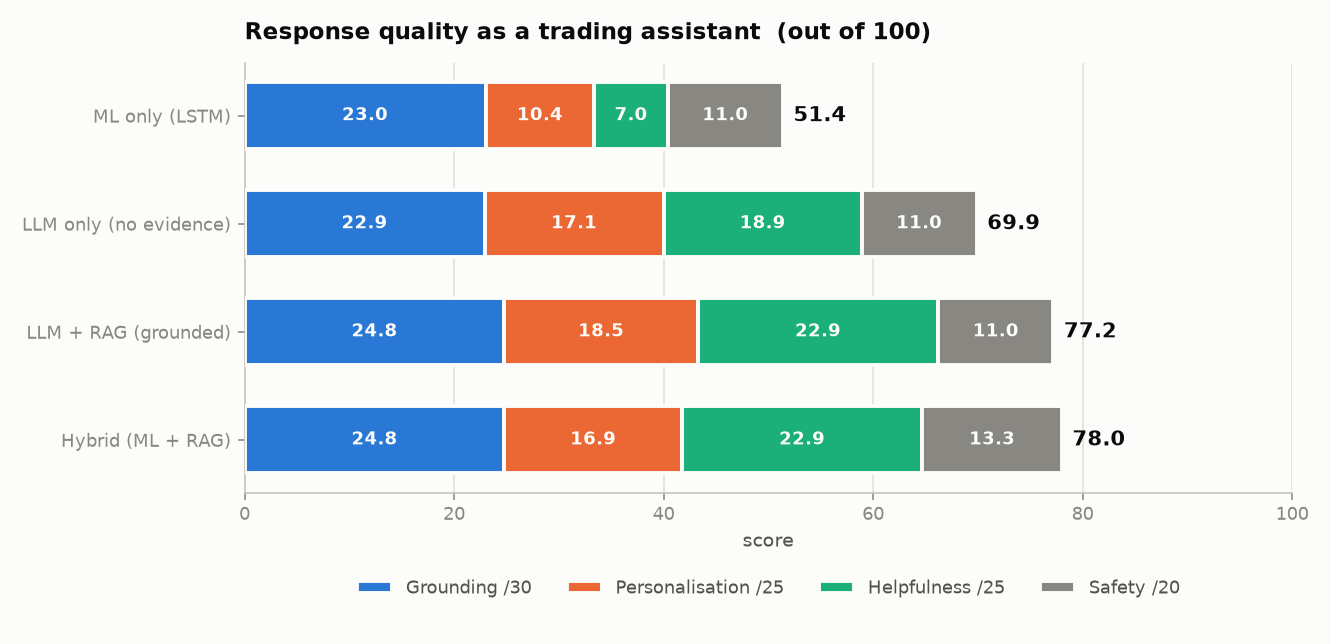

In [26]:
def fig_response_quality(results):
    """The rubric, stacked by dimension.

    Stacked rather than grouped because the question the chart has to answer is
    "where does the score come from", not "which bar is tallest" - the totals are
    close and the interesting content is which dimension separates the arms.
    """
    rq = results.get('response_quality')
    if not rq:
        return None
    dims    = ['grounding', 'personalisation', 'helpfulness', 'safety']
    labels  = ['Grounding /30', 'Personalisation /25', 'Helpfulness /25', 'Safety /20']
    colours = [BLUE, ORANGE, AQUA, MUTED]
    short = {'ML': 'ML only (LSTM)', 'LLM': 'LLM only (no evidence)',
             'LLM_RAG': 'LLM + RAG (grounded)', 'HYBRID': 'Hybrid (ML + RAG)'}
    arms = [a for a in ['ML', 'LLM', 'LLM_RAG', 'HYBRID'] if a in rq['scores']]

    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    left = np.zeros(len(arms))
    for dim, label, colour in zip(dims, labels, colours):
        vals = np.array([rq['scores'][a][dim] for a in arms])
        bars = ax.barh(range(len(arms)), vals, left=left, color=colour, height=.62,
                       label=label, zorder=3)
        for b in bars:            # 2px surface gap between adjacent segments
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 2.2:
                ax.text(l + v / 2, i, f'{v:.1f}', ha='center', va='center', color=SURFACE,
                        fontsize=9, fontweight='600', zorder=4)
        left += vals
    for i, a in enumerate(arms):
        ax.text(left[i] + 1.0, i, f"{rq['scores'][a]['total']:.1f}", va='center',
                fontsize=11, fontweight='700', color=INK, zorder=4)
    ax.set_yticks(range(len(arms)), [short.get(a, a) for a in arms], fontsize=9.5, color=INK2)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK2, ncol=4,
              loc='lower center', bbox_to_anchor=(0.5, -0.28))
    style_axes(ax, title='Response quality as a trading assistant  (out of 100)',
               xlabel='score', grid_axis='x')
    return save_fig(fig, 'fig6_response_quality.png')


fig_response_quality(results)
display(Image(filename=str(OUT / 'fig6_response_quality.png')))

### Two supporting figures

`fig4` shows how the hybrid behaves across every possible trust weight — the curve is drawn on the
holdout, but the weight marked on it was derived on the tuning split alone. Showing both together
is the point: the curve is flat near the middle, which is the justification for shrinking the weight
towards an equal blend rather than trusting a peak found on 200 rows. `fig5` asks who is right when
the two arms disagree.

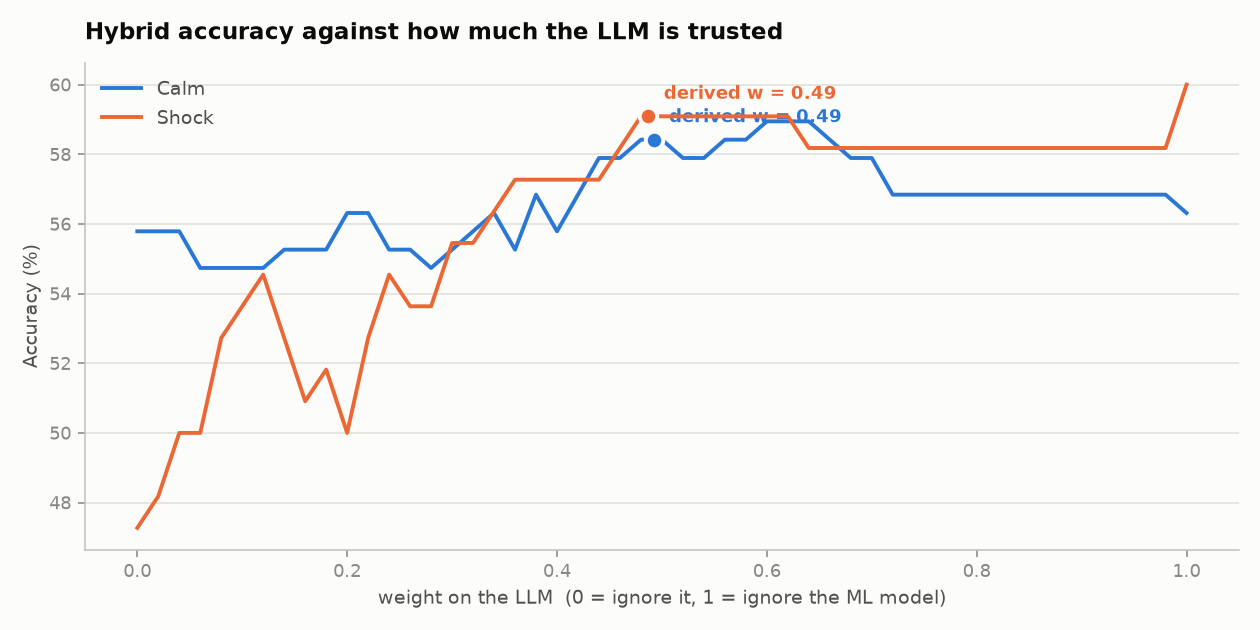

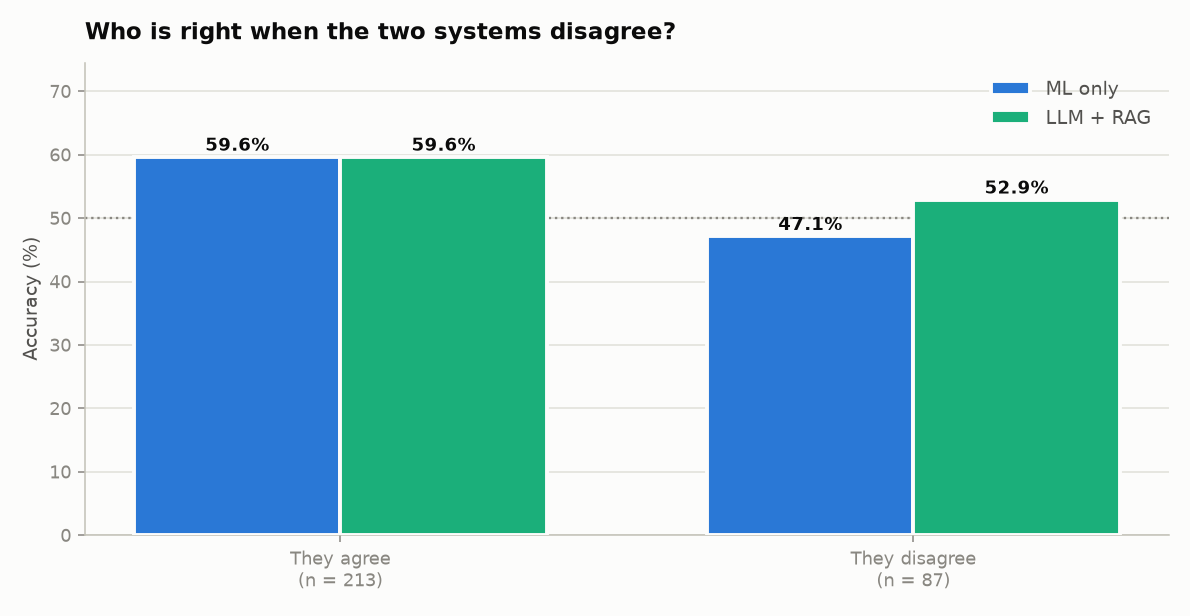

In [27]:
def fig_weights(preds, results):
    """Hybrid accuracy across every possible trust weight, per regime."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    grid  = C.WEIGHT_GRID
    t_ml  = float(results.get('thresholds', {}).get('ML', 0.5))
    t_llm = float(results.get('thresholds', {}).get('LLM_RAG', 0.5))
    hold = preds[preds['split'] == 'holdout'] if 'split' in preds.columns else preds

    for regime, colour in (('CALM', BLUE), ('SHOCK', ORANGE)):
        sub = hold[hold['regime'] == regime]
        if not len(sub):
            continue
        accs = [((H.fuse(sub['p_ML'].values, sub['p_LLM_RAG'].values, w, t_ml=t_ml, t_llm=t_llm)
                  >= 0.5).astype(int) == sub['y_true'].values).mean() * 100 for w in grid]
        ax.plot(grid, accs, color=colour, linewidth=2, label=regime.title(), zorder=3)
        chosen = results['weights'].get(regime)
        if chosen is not None:
            at = accs[min(range(len(grid)), key=lambda i: abs(grid[i] - chosen))]
            ax.plot([chosen], [at], 'o', color=colour, markersize=9,
                    markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
            ax.annotate(f'derived w = {chosen:.2f}', (chosen, at), textcoords='offset points',
                        xytext=(8, 9), color=colour, fontsize=9.5, fontweight='600')
    ax.legend(frameon=False, fontsize=10, labelcolor=INK2)
    style_axes(ax, title='Hybrid accuracy against how much the LLM is trusted',
               xlabel='weight on the LLM  (0 = ignore it, 1 = ignore the ML model)',
               ylabel='Accuracy (%)')
    return save_fig(fig, 'fig4_weight_search.png')


def fig_agreement(preds):
    """Where the systems disagree - and who is right when they do."""
    d = (preds[preds['split'] == 'holdout'] if 'split' in preds.columns else preds).copy()
    d['ml_up']  = (d['p_ML'] >= 0.5).astype(int)
    d['rag_up'] = (d['p_LLM_RAG'] >= 0.5).astype(int)
    d['agree']  = d['ml_up'] == d['rag_up']

    groups, ml_acc, rag_acc, ns = [], [], [], []
    for label, sub in (('They agree', d[d['agree']]), ('They disagree', d[~d['agree']])):
        if not len(sub):
            continue
        groups.append(label)
        ml_acc.append((sub['ml_up'] == sub['y_true']).mean() * 100)
        rag_acc.append((sub['rag_up'] == sub['y_true']).mean() * 100)
        ns.append(len(sub))

    x, w = np.arange(len(groups)), 0.36
    fig, ax = plt.subplots(figsize=(8.5, 4.4))
    for i, (vals, colour, label) in enumerate([(ml_acc, BLUE, 'ML only'),
                                               (rag_acc, AQUA, 'LLM + RAG')]):
        bars = ax.bar(x + (i - 0.5) * w, vals, width=w, color=colour, label=label, zorder=3)
        for b in bars:
            b.set_linewidth(2)
            b.set_edgecolor(SURFACE)
        for xi, v in zip(x + (i - 0.5) * w, vals):
            ax.text(xi, v + 1, f'{v:.1f}%', ha='center', fontsize=9.5, color=INK, fontweight='600')
    ax.axhline(50, color=MUTED, linewidth=1.2, linestyle=':', zorder=2)
    ax.set_xticks(x, [f'{g}\n(n = {n})' for g, n in zip(groups, ns)], fontsize=10, color=INK2)
    ax.legend(frameon=False, fontsize=10, labelcolor=INK2)
    style_axes(ax, title='Who is right when the two systems disagree?', ylabel='Accuracy (%)')
    ax.set_ylim(0, max(ml_acc + rag_acc) * 1.25)
    return save_fig(fig, 'fig5_agreement.png')


fig_weights(preds, results)
fig_agreement(preds)
display(Image(filename=str(OUT / 'fig4_weight_search.png')))
display(Image(filename=str(OUT / 'fig5_agreement.png')))

---
# 11. Results summary

| Claim | Evidence | Result |
|---|---|---|
| No architecture on price history clears the baseline | §2 | best of five = 54.8% vs 55.0% always-UP; every AUC in [50.0, 51.1] |
| The choice of recurrent cell does not matter here | §2 | GRU leads by 2.1pt in shocks, McNemar p = 0.39; consistency across folds and stocks does not separate them either |
| The LSTM collapses in shocks, the grounded LLM holds up | §7 | 47.3% vs 60.0%, McNemar p ≈ 0.08 — directional, not proven |
| Retrieval changes behaviour, not just wording | §7, §10 | +1.7pp accuracy; +7.3 response-quality points |
| Raw-probability fusion fails; calibrated pooling fixes it | §6, §7 | 53.7% → 58.3% on identical responses |
| Nobody beats the market | §7 | oracle ceiling 82.7%; all arms within each other's CI |
| The LLM contradicts itself; the ML model cannot | §9 | 3.3% flip rate, all in shocks — but n = 1 case |
| The hybrid does **not** inherit determinism | §9 | variance halved (0.505×), flip rate identical |
| Grounding drives assistant quality; fusion adds ~1 point | §10 | 51.4 → 69.9 → 77.2 → 78.0 / 100 |

**The through-line.** The comparison in §2 is what licenses everything after it. Five architectures,
identical folds, identical features — and none of them clears a baseline that predicts UP every day.
The two recurrent nets are not even distinguishable from each other. That is not a failed stage; it
is the measurement that makes the rest of the notebook necessary. If more architecture on the same
information cannot help, the only remaining move is different information — which is what §3 onwards
tests, and where the grounded LLM finally does something the price history alone could not.

**Limitations.** 300 holdout rows, 5 stocks, one horizon, one period, one LLM. Every accuracy
interval overlaps every other. The GRU/LSTM comparison rests on a single seed per fold, so the tie
should be read as "not distinguishable on this evidence" rather than "proven equal". The stability
result rests on a single flipped case. The rubric's weights are argued but not validated against
human ratings, and 42 of its 100 points are earned identically by all four arms.

**Where the comparison is demonstrated.** `app.py` runs all four arms live on one question and shows
the direction, the confidence, the reasoning, the retrieved evidence, an automatic hallucination
verdict, and — because every date is historical — whether each system was actually right. The
numbers above are the evidence; the demo is where the behaviour is visible.

In [28]:
print('=' * 72)
print(f"{'Selected ML arm':26} {sel['selected']} ({sel['family']}) - {sel['criterion']}")
print('=' * 72)
for a in C.ARM_DISPLAY_ORDER:
    print(f"{C.ARM_LABELS.get(a, a):26} accuracy {acc[a]['overall']:>5.2f}%   "
          f"brier(cal) {results['brier_calibrated'][a]:.4f}   "
          f"quality {s_[a]['total']:>5.1f}/100")
print(f"{'Baseline: always UP':26} accuracy {acc['BASELINE_ALWAYS_UP']['overall']:>5.2f}%")
print('=' * 72)
print('\nThe live four-arm comparison:  python app.py  ->  http://localhost:5000')

Selected ML arm            LSTM (Deep learning) - highest shock-regime accuracy, confirmed by paired McNemar
Hybrid (ML + RAG-LLM)      accuracy 58.33%   brier(cal) 0.2447   quality  78.0/100
LLM + RAG (grounded)       accuracy 57.67%   brier(cal) 0.2505   quality  77.2/100
LLM only (no evidence)     accuracy 56.00%   brier(cal) 0.2509   quality  69.9/100
ML only (LSTM)             accuracy 52.67%   brier(cal) 0.2507   quality  51.4/100
Baseline: always UP        accuracy 54.33%

The live four-arm comparison:  python app.py  ->  http://localhost:5000
